In [3]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")
df=pd.read_csv('credit_score.csv', encoding='latin-1')
df.head()

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
2,0x1604,CUS_0xd40,March,Aaron Maashoh,-500,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good
3,0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
4,0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good


In [4]:
df.columns

Index(['ID', 'Customer_ID', 'Month', 'Name', 'Age', 'SSN', 'Occupation',
       'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
       'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Type_of_Loan',
       'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt',
       'Credit_Utilization_Ratio', 'Credit_History_Age',
       'Payment_of_Min_Amount', 'Total_EMI_per_month',
       'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance',
       'Credit_Score'],
      dtype='str')

In [5]:
df.shape

(100000, 28)

In [6]:
m=df['Month']=='January'
df1=df[m]
df1

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
8,0x160e,CUS_0x21b1,January,Rick Rothackerj,28_,004-07-5839,_______,34847.84,3037.986667,2,...,Good,605.03,24.464031,26 Years and 7 Months,No,18.816215,104.291825168246,Low_spent_Small_value_payments,470.69062692529184,Standard
16,0x161a,CUS_0x2dbc,January,Langep,34,486-85-3974,_______,143162.64,12187.220000,1,...,Good,1303.01,28.616735,17 Years and 9 Months,No,246.992319,168.413702679309,!@9#%8,1043.3159778669492,Good
24,0x1626,CUS_0xb891,January,Jasond,54,072-31-6145,Entrepreneur,30689.89,2612.490833,2,...,Good,632.46,26.544229,17 Years and 3 Months,No,16.415452,81.22885871073616,Low_spent_Large_value_payments,433.6047729627723,Standard
32,0x1632,CUS_0x1cdb,January,Deepaa,21,615-06-7821,Developer,35547.71_,2853.309167,7,...,Standard,943.86,39.797764,30 Years and 8 Months,Yes,0.000000,276.72539431736266,!@9#%8,288.60552234930395,Standard
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99960,0x25fb6,CUS_0x372c,January,Lucia Mutikanik,18,340-85-7301,Lawyer,42903.79,3468.315833,0,...,Good,1079.48,27.289440,28 Years and 1 Months,No,50894.000000,78.51494451125625,High_spent_Small_value_payments,493.341182,Good
99968,0x25fc2,CUS_0xf16,January,Maria Sheahanb,44,#F%$D@*&8,Media_Manager,16680.35,1528.029167,1,...,Good,897.16,39.868572,NaN,NM,41.113561,52.95197781627658,High_spent_Small_value_payments,318.737378,Good
99976,0x25fce,CUS_0xaf61,January,Chris Wickhamm,49,133-16-7738,Writer,37188.1,3097.008333,1,...,Good,620.64,39.080823,29 Years and 9 Months,No,84.205949,223.87501818278344,Low_spent_Small_value_payments,291.619866,Good
99984,0x25fda,CUS_0x8600,January,Sarah McBridec,28,031-35-0942,Architect,20002.88,1929.906667,10,...,Bad,3571.7_,22.895966,5 Years and 8 Months,Yes,60.964772,43.37067007268804,High_spent_Large_value_payments,328.655224,Poor


In [7]:
df1.drop(['ID', 'Customer_ID', 'Month', 'Name', 'SSN', 'Type_of_Loan'], axis=1, inplace=True, errors='ignore')
df1

,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,23,Scientist,19114.12,1824.843333,3,4,3,4,3,7,...,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
8,28_,_______,34847.84,3037.986667,2,4,6,1,3,4,...,Good,605.03,24.464031,26 Years and 7 Months,No,18.816215,104.291825168246,Low_spent_Small_value_payments,470.69062692529184,Standard
16,34,_______,143162.64,12187.220000,1,5,8,3,5,8,...,Good,1303.01,28.616735,17 Years and 9 Months,No,246.992319,168.413702679309,!@9#%8,1043.3159778669492,Good
24,54,Entrepreneur,30689.89,2612.490833,2,5,4,1,0,6,...,Good,632.46,26.544229,17 Years and 3 Months,No,16.415452,81.22885871073616,Low_spent_Large_value_payments,433.6047729627723,Standard
32,21,Developer,35547.71_,2853.309167,7,5,5,0,5,NaN,...,Standard,943.86,39.797764,30 Years and 8 Months,Yes,0.000000,276.72539431736266,!@9#%8,288.60552234930395,Standard
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99960,18,Lawyer,42903.79,3468.315833,0,4,6,1,14,0,...,Good,1079.48,27.289440,28 Years and 1 Months,No,50894.000000,78.51494451125625,High_spent_Small_value_payments,493.341182,Good
99968,44,Media_Manager,16680.35,1528.029167,1,1,5,4,4,0,...,Good,897.16,39.868572,NaN,NM,41.113561,52.95197781627658,High_spent_Small_value_payments,318.737378,Good
99976,49,Writer,37188.1,3097.008333,1,4,5,3,7,12,...,Good,620.64,39.080823,29 Years and 9 Months,No,84.205949,223.87501818278344,Low_spent_Small_value_payments,291.619866,Good
99984,28,Architect,20002.88,1929.906667,10,8,29,5_,35,26,...,Bad,3571.7_,22.895966,5 Years and 8 Months,Yes,60.964772,43.37067007268804,High_spent_Large_value_payments,328.655224,Poor


In [8]:
df1.isnull().sum()

Age                            0
Occupation                     0
Annual_Income                  0
Monthly_Inhand_Salary       1861
Num_Bank_Accounts              0
Num_Credit_Card                0
Interest_Rate                  0
Num_of_Loan                    0
Delay_from_due_date            0
Num_of_Delayed_Payment       843
Changed_Credit_Limit           0
Num_Credit_Inquiries         236
Credit_Mix                     0
Outstanding_Debt               0
Credit_Utilization_Ratio       0
Credit_History_Age          1113
Payment_of_Min_Amount          0
Total_EMI_per_month            0
Amount_invested_monthly      565
Payment_Behaviour              0
Monthly_Balance              134
Credit_Score                   0
dtype: int64

In [9]:
df1.shape

(12500, 22)

In [10]:
pip install missingno

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
import missingno as mn

<Axes: >

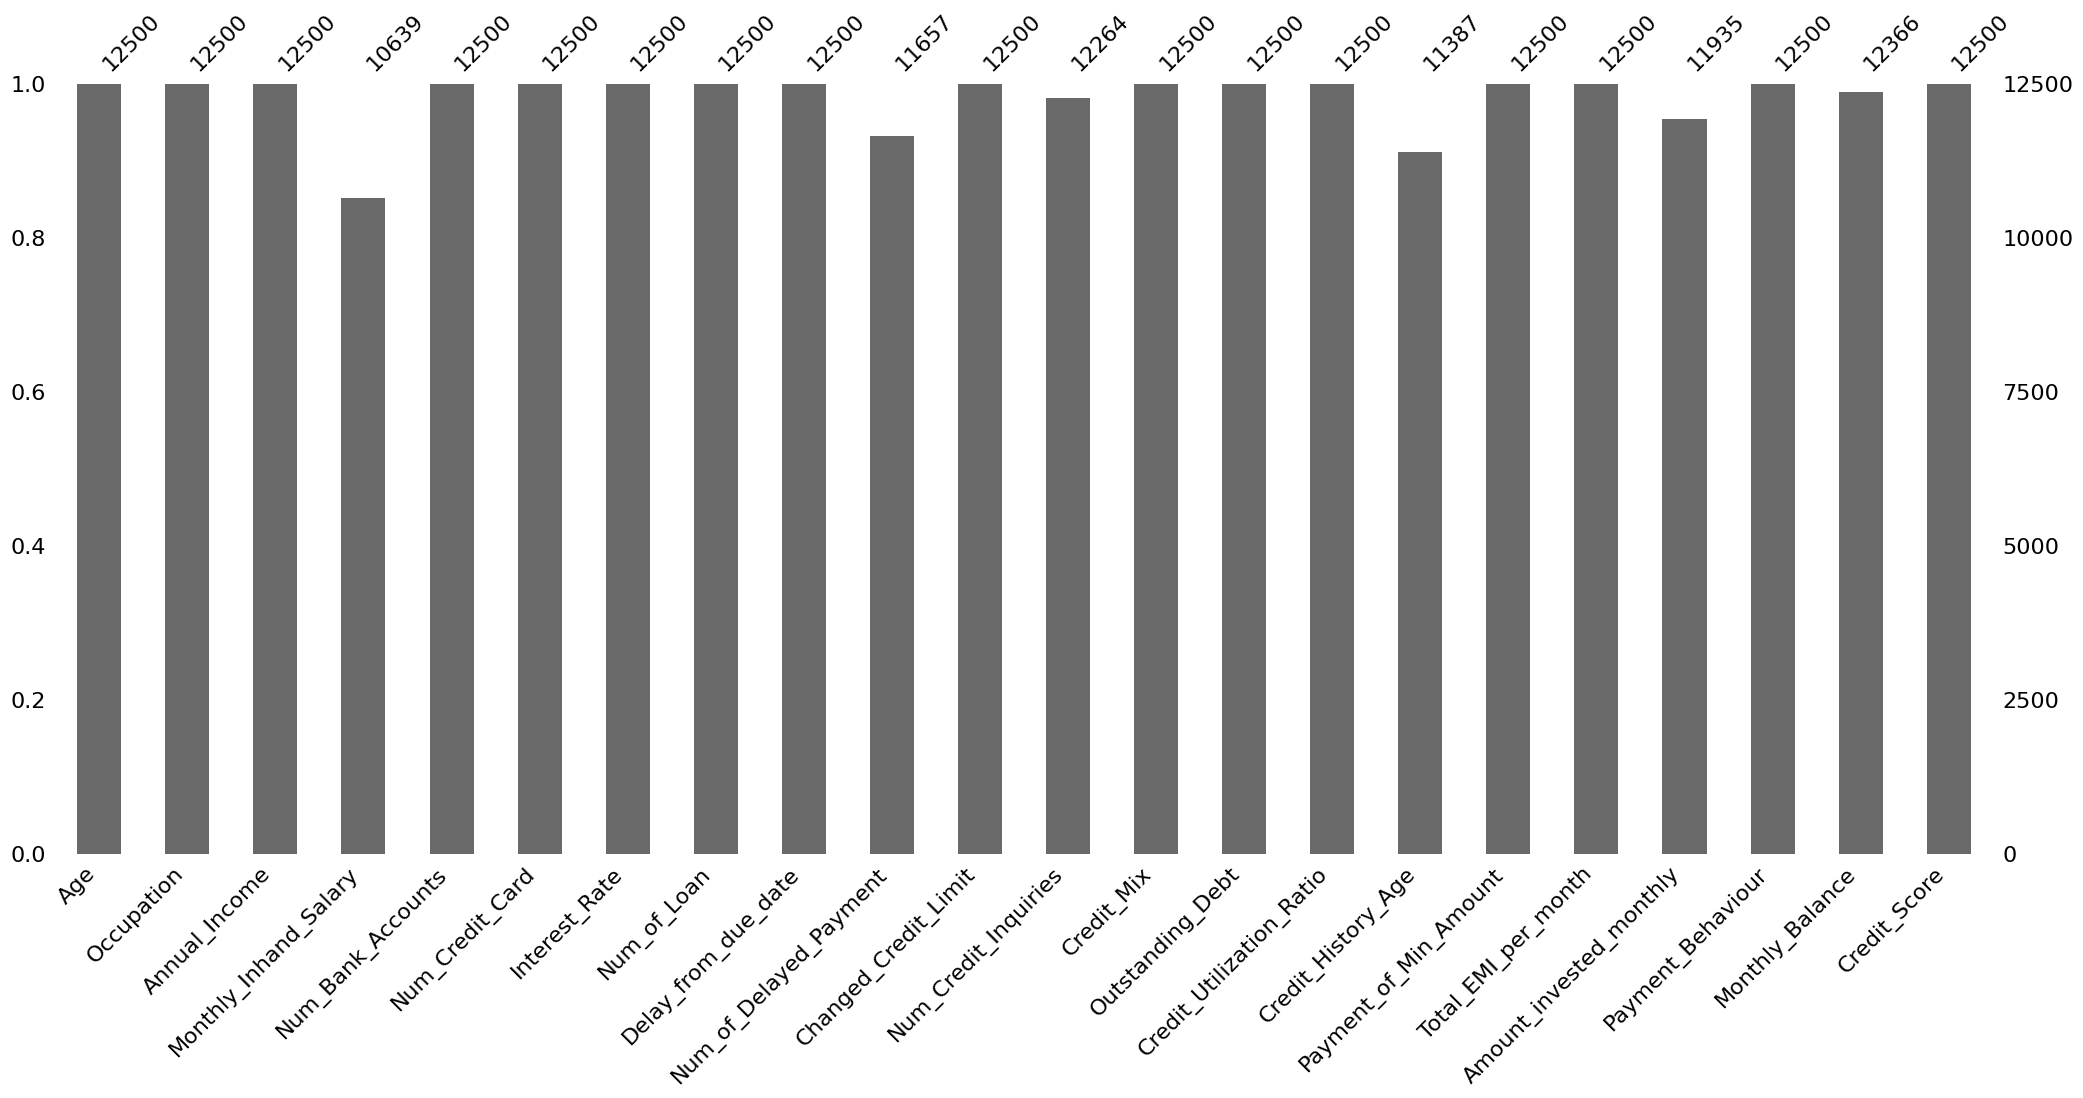

In [12]:
mn.bar(df1)

<Axes: >

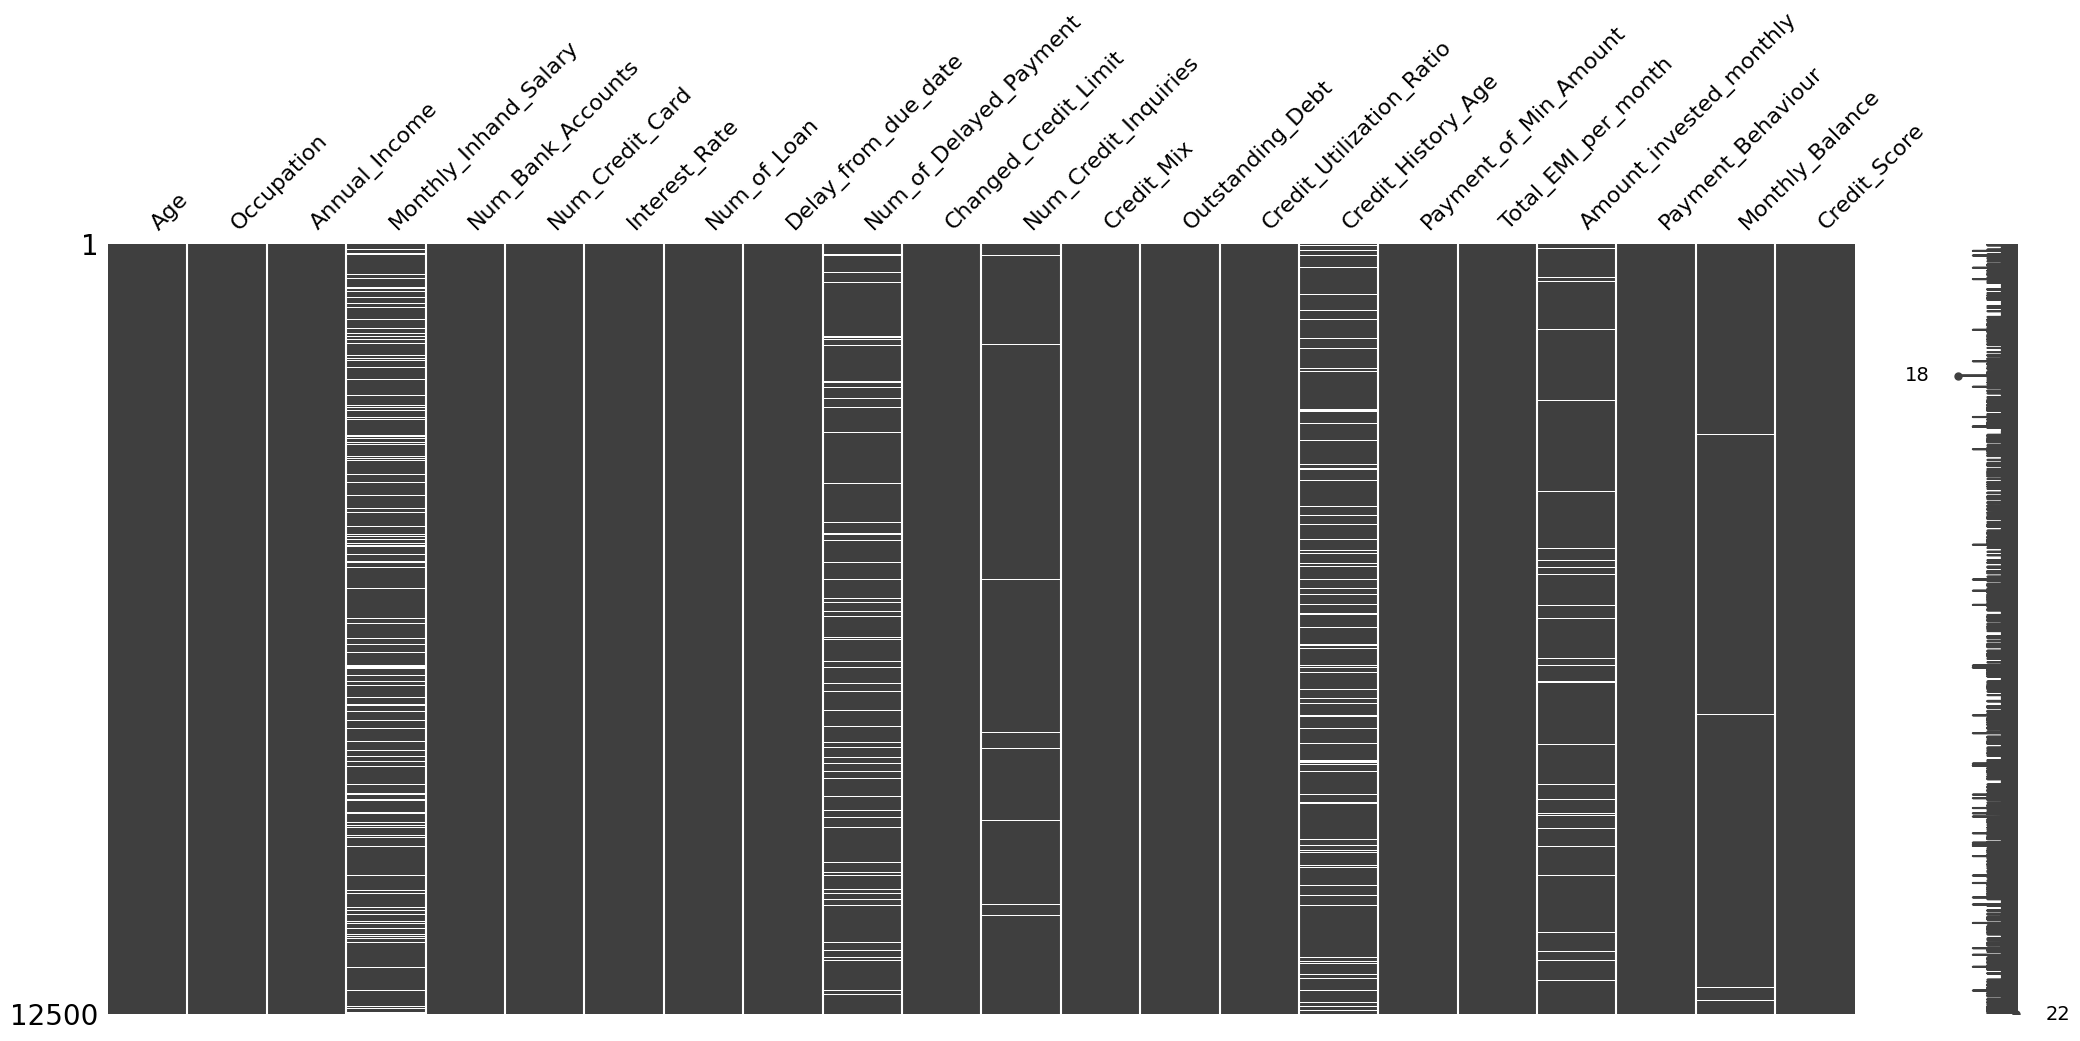

In [13]:
mn.matrix(df1)

In [14]:
df1['Age']=df1['Age'].astype(str).str.replace(r'\D', ' ' , regex=True).astype(int)

In [15]:
m=df1['Age']<=90
df1=df1[m]
df1
df1['Occupation']=df1['Occupation'].replace("_______", "other")
df1['Annual_Income']=df1['Annual_Income'].astype(str).str.replace(r'\D', '' , regex=True).astype(int)
df1['Num_of_Loan']=df1['Num_of_Loan'].astype(str).str.replace(r'\D', '' , regex=True).astype(int)
df1['Outstanding_Debt']=df1['Outstanding_Debt'].astype(str).str.replace(r'\D', '' , regex=True).astype(int)
df1['Changed_Credit_Limit']=df['Changed_Credit_Limit'].astype(str).str.replace('_', '0').astype(float)
df1.isnull().sum()


Age                            0
Occupation                     0
Annual_Income                  0
Monthly_Inhand_Salary       1805
Num_Bank_Accounts              0
Num_Credit_Card                0
Interest_Rate                  0
Num_of_Loan                    0
Delay_from_due_date            0
Num_of_Delayed_Payment       822
Changed_Credit_Limit           0
Num_Credit_Inquiries         234
Credit_Mix                     0
Outstanding_Debt               0
Credit_Utilization_Ratio       0
Credit_History_Age          1081
Payment_of_Min_Amount          0
Total_EMI_per_month            0
Amount_invested_monthly      542
Payment_Behaviour              0
Monthly_Balance              131
Credit_Score                   0
dtype: int64

In [16]:
df1

,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,23,Scientist,1911412,1824.843333,3,4,3,4,3,7,...,_,80998,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
8,28,other,3484784,3037.986667,2,4,6,1,3,4,...,Good,60503,24.464031,26 Years and 7 Months,No,18.816215,104.291825168246,Low_spent_Small_value_payments,470.69062692529184,Standard
16,34,other,14316264,12187.220000,1,5,8,3,5,8,...,Good,130301,28.616735,17 Years and 9 Months,No,246.992319,168.413702679309,!@9#%8,1043.3159778669492,Good
24,54,Entrepreneur,3068989,2612.490833,2,5,4,1,0,6,...,Good,63246,26.544229,17 Years and 3 Months,No,16.415452,81.22885871073616,Low_spent_Large_value_payments,433.6047729627723,Standard
32,21,Developer,3554771,2853.309167,7,5,5,0,5,NaN,...,Standard,94386,39.797764,30 Years and 8 Months,Yes,0.000000,276.72539431736266,!@9#%8,288.60552234930395,Standard
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99960,18,Lawyer,4290379,3468.315833,0,4,6,1,14,0,...,Good,107948,27.289440,28 Years and 1 Months,No,50894.000000,78.51494451125625,High_spent_Small_value_payments,493.341182,Good
99968,44,Media_Manager,1668035,1528.029167,1,1,5,4,4,0,...,Good,89716,39.868572,NaN,NM,41.113561,52.95197781627658,High_spent_Small_value_payments,318.737378,Good
99976,49,Writer,371881,3097.008333,1,4,5,3,7,12,...,Good,62064,39.080823,29 Years and 9 Months,No,84.205949,223.87501818278344,Low_spent_Small_value_payments,291.619866,Good
99984,28,Architect,2000288,1929.906667,10,8,29,5,35,26,...,Bad,35717,22.895966,5 Years and 8 Months,Yes,60.964772,43.37067007268804,High_spent_Large_value_payments,328.655224,Poor


In [17]:
df1['Num_of_Delayed_Payment'] = pd.to_numeric(df1['Num_of_Delayed_Payment'], errors='coerce').fillna(0).astype(int)
m = df1['Num_of_Delayed_Payment'] <= 100
df1 = df1.loc[m].copy()
m = df1['Num_Credit_Inquiries'] <= 12.0
df1 = df1.loc[m].copy()
df1['Credit_Mix'] = df1['Credit_Mix'].replace('_', 'Standard')
df1['Monthly_Inhand_Salary'] = pd.to_numeric(df1['Monthly_Inhand_Salary'], errors='coerce')
df1['Monthly_Inhand_Salary'] = df1['Monthly_Inhand_Salary'].fillna(df1['Monthly_Inhand_Salary'].median())
df1['Monthly_Inhand_Salary'].head()
df1['Monthly_Balance'] = df1['Monthly_Balance'].fillna(0, inplace= True)
df1['Monthly_Balance ']=df1['Monthly_Balance'].astype(str).str.replace(r'\D', '' , regex=True).astype(int)

df1['Amount_invested_monthly'] = df1['Amount_invested_monthly'].astype(str).str.replace(r'\D', '' , regex=True).astype(float)
df1['Amount_invested_monthly'] = df1['Amount_invested_monthly'].fillna(0, inplace= True)
df1['Payment_Behaviour']=df1['Payment_Behaviour'].replace("!@9#%8", "Not Specified", inplace= True) 
                                                      

df1.head(30)

,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,...,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score,Monthly_Balance
0,23,Scientist,1911412,1824.843333,3,4,3,4,3,7,...,80998,26.822620,22 Years and 1 Months,No,49.574949,8.041530e+15,High_spent_Small_value_payments,312.49408867943663,Good,31249408867943663
8,28,other,3484784,3037.986667,2,4,6,1,3,4,...,60503,24.464031,26 Years and 7 Months,No,18.816215,1.042918e+14,Low_spent_Small_value_payments,470.69062692529184,Standard,47069062692529184
16,34,other,14316264,12187.220000,1,5,8,3,5,8,...,130301,28.616735,17 Years and 9 Months,No,246.992319,1.684137e+14,Not Specified,1043.3159778669492,Good,10433159778669492
24,54,Entrepreneur,3068989,2612.490833,2,5,4,1,0,6,...,63246,26.544229,17 Years and 3 Months,No,16.415452,8.122886e+15,Low_spent_Large_value_payments,433.6047729627723,Standard,4336047729627723
32,21,Developer,3554771,2853.309167,7,5,5,0,5,0,...,94386,39.797764,30 Years and 8 Months,Yes,0.000000,2.767254e+16,Not Specified,288.60552234930395,Standard,28860552234930395
40,31,Lawyer,7392846,3081.940000,4,1288,8,0,12,10,...,5482,39.962685,NaN,No,15015.000000,9.867441e+15,High_spent_Large_value_payments,740.1960900583389,Good,7401960900583389
48,33,Lawyer,1313134,11242.783333,0,1,8,2,0,3,...,35216,32.200509,30 Years and 7 Months,NM,137.644605,3.781713e+15,High_spent_Medium_value_payments,858.462474411158,Good,858462474411158
64,23,Doctor,11483841,9843.867500,2,5,7,100,13,11,...,137774,33.664554,21 Years and 4 Months,No,226.892792,2.151935e+16,High_spent_Small_value_payments,802.3004421328528,Good,8023004421328528
72,44,Journalist,313708,2825.233333,0,5,12,2,4,0,...,42143,29.519353,NaN,NM,46.616129,1.543528e+14,High_spent_Small_value_payments,341.55442316289026,Good,34155442316289026
80,40,Teacher,3375127,2948.605833,5,5,20,3,16,20,...,132893,37.089076,19 Years and 2 Months,NM,65.008174,1.173067e+16,High_spent_Medium_value_payments,362.54571194023237,Standard,36254571194023237


In [18]:
def credit_month(x):
    try:
        column= x.split("and")
        years=int(column[0].stripp.split()[0])
        months=int(column[0].stripp.split()[0])
        return years*12 + months
    except:
        return None
df1['Credit_History_Age_month'] = df1['Credit_History_Age'].apply(credit_month)
df1.drop(['Credit_History_Age'], axis=1, inplace=True)
df1['Credit_History_Age_month'] = df1['Credit_History_Age_month'].fillna(0, inplace= True)

In [19]:
df1.info()

<class 'pandas.DataFrame'>
Index: 11621 entries, 0 to 99992
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       11621 non-null  int64  
 1   Occupation                11621 non-null  str    
 2   Annual_Income             11621 non-null  int64  
 3   Monthly_Inhand_Salary     11621 non-null  float64
 4   Num_Bank_Accounts         11621 non-null  int64  
 5   Num_Credit_Card           11621 non-null  int64  
 6   Interest_Rate             11621 non-null  int64  
 7   Num_of_Loan               11621 non-null  int64  
 8   Delay_from_due_date       11621 non-null  int64  
 9   Num_of_Delayed_Payment    11621 non-null  int64  
 10  Changed_Credit_Limit      11621 non-null  float64
 11  Num_Credit_Inquiries      11621 non-null  float64
 12  Credit_Mix                11621 non-null  str    
 13  Outstanding_Debt          11621 non-null  int64  
 14  Credit_Utilization_Rat

In [20]:
(df1['Num_Bank_Accounts']>20).sum()

np.int64(149)

In [21]:
df1.loc[df1['Num_Bank_Accounts']>20, 'Num_Bank_Accounts']=np.random.randint(0, 6, size=(df1['Num_Bank_Accounts']>20).sum())

In [22]:
df1.loc[df1['Num_Credit_Card']>20, 'Num_Credit_Card']=np.random.randint(0, 6, size=(df1['Num_Credit_Card']>20).sum())

In [23]:
df1.loc[df1['Interest_Rate']>50, 'Interest_Rate']=np.random.randint(0, 6, size=(df1['Interest_Rate']>50).sum())

In [24]:
df1.loc[df1['Num_Credit_Inquiries']>30, 'Num_Credit_Inquiries']=np.random.randint(0, 6, size=(df1['Num_Credit_Inquiries']>30).sum())

In [25]:
df1.loc[df1['Num_of_Loan']>200, 'Num_of_Loan']=np.random.randint(0, 6, size=(df1['Num_of_Loan']>200).sum())

In [26]:
df1.describe()

,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Outstanding_Debt,Credit_Utilization_Ratio,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance
count,11621.000000,1.162100e+04,11621.000000,11621.000000,11621.000000,11621.000000,11621.000000,11621.000000,11621.000000,11621.000000,11621.000000,11621.000000,11621.000000,11621.000000,1.162100e+04,1.162100e+04
mean,33.052491,1.596688e+14,4037.343838,5.337579,5.461148,14.328199,7.489545,21.106531,12.054729,10.235382,4.930901,128933.629894,32.286013,1281.679539,1.165835e+16,1.418434e+16
std,10.771288,1.151494e+15,2977.401756,2.594922,2.115139,8.818158,19.297044,14.884218,7.229382,6.856237,3.540271,115608.671337,5.084878,8033.950907,1.269999e+16,1.394533e+16
min,14.000000,7.046500e+04,303.645417,0.000000,0.000000,0.000000,0.000000,-5.000000,-3.000000,-6.430000,0.000000,12.000000,20.992914,0.000000,0.000000e+00,0.000000e+00
25%,24.000000,1.829089e+06,1784.052500,3.000000,4.000000,7.000000,2.000000,10.000000,7.000000,5.090000,2.000000,39884.000000,28.118877,29.106311,2.628447e+15,3.223505e+15
50%,33.000000,3.844452e+06,3081.940000,5.000000,5.000000,13.000000,3.000000,18.000000,12.000000,9.340000,4.000000,102571.000000,32.263362,66.158038,7.755870e+15,6.489405e+15
75%,41.000000,8.366952e+06,5404.491667,7.000000,7.000000,20.000000,6.000000,28.000000,18.000000,14.680000,8.000000,174708.000000,36.449554,149.684408,1.550112e+16,2.631947e+16
max,55.000000,1.349284e+16,15204.633333,10.000000,17.000000,34.000000,143.000000,67.000000,84.000000,36.490000,12.000000,499807.000000,49.564519,82122.000000,6.398399e+16,6.359929e+16



Age:	Customer’s age

Occupation: Customer’s profession or job

Annual_Income:	Customer’s yearly income

Monthly_Inhand_Salary:	Customer’s monthly take-home salary

Num_Bank_Accounts:	Number of bank accounts owned by the customer

Num_Credit_Card:	Number of credit cards owned by the customer

Interest_Rate:	Interest rate charged on loans or credit

Num_of_Loan:	Number of loans taken by the customer

Delay_from_due_date:	Number of days payment was delayed after the due date

Num_of_Delayed_Payment:	Total number of delayed payments

Changed_Credit_Limit:	Change in the customer’s credit limit

Num_Credit_Inquiries:	Number of credit report inquiries

Credit_Mix:	Combination and quality of the customer’s credit accounts

Outstanding_Debt:	Total debt that is still unpaid

Credit_Utilization_Ratio:	Percentage of available credit currently being used

Credit_History_Age:	Length of the customer’s credit history

Payment_of_Min_Amount:	Whether the customer pays the minimum amount due

Total_EMI_per_month:	Total monthly EMI paid by the customer

Amount_invested_monthly:	Amount invested by the customer every month

Payment_Behaviour:	Customer’s payment and spending behavior

Monthly_Balance:	Balance remaining at the end of the month

Credit_Score:	Customer’s credit rating, such as Good, Standard, or Poor

Univariate Data Analysis

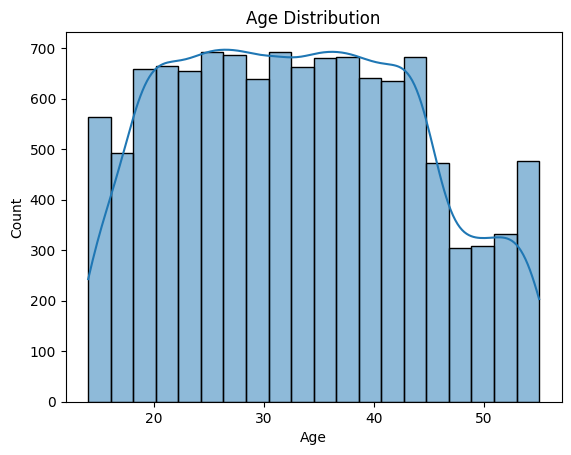

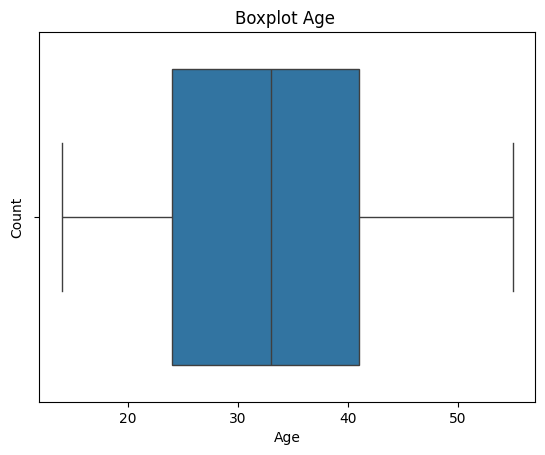

stat 0.9723839227162953 p 2.6190446347596754e-42


In [27]:
import matplotlib.pyplot as plt
from scipy.stats import shapiro
import seaborn as sns


sns.histplot(data=df1, x='Age', bins=20, kde=True)
plt.xlabel('Age')
plt.ylabel('Count')
plt.title('Age Distribution')
plt.show()
sns.boxplot(data=df1, x='Age')
plt.xlabel('Age')
plt.ylabel('Count')
plt.title('Boxplot Age ')
plt.show()
stat,p=shapiro(df1['Age'])
print("stat", stat, "p",p)

bar graph show tha age is normally distributed but In shapiro test p<0.05 reject null hypothesis means age is not normal.

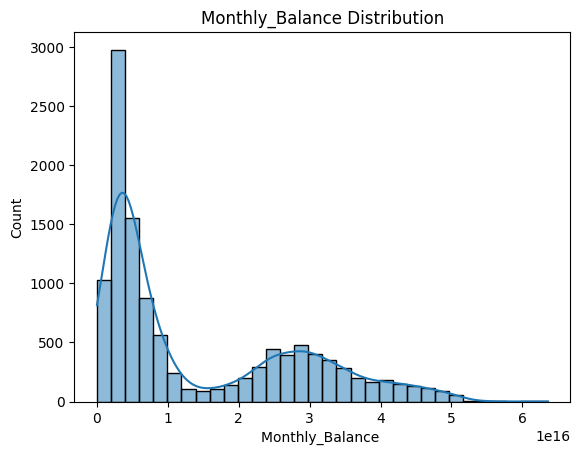

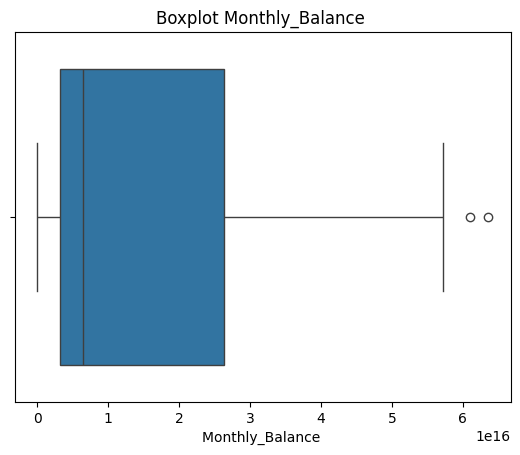

In [28]:
df1['Monthly_Balance '].describe()
sns.histplot(df1['Monthly_Balance '], kde=True)
plt.title('Monthly_Balance Distribution')
plt.show()
sns.boxplot(x=df1['Monthly_Balance '])
plt.title('Boxplot Monthly_Balance ')
plt.show()

Monthly balace show bidignoal graph and two outlier are persent.

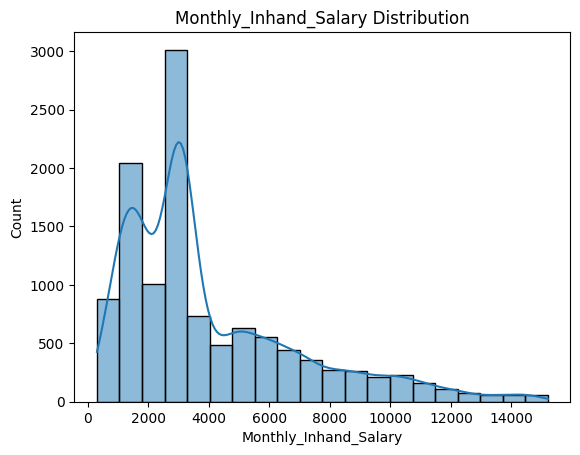

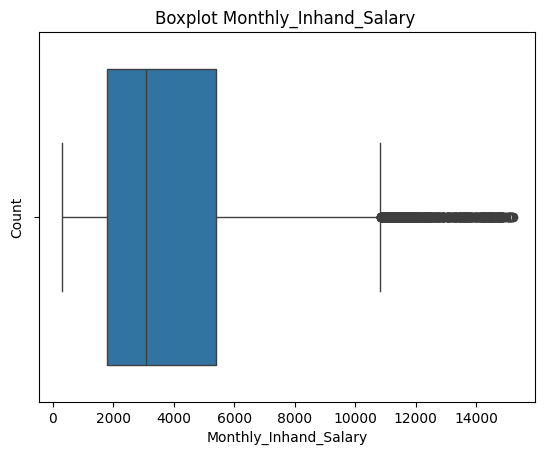

In [29]:
sns.histplot(data=df1, x='Monthly_Inhand_Salary', bins=20, kde=True)
plt.xlabel('Monthly_Inhand_Salary')
plt.ylabel('Count')
plt.title('Monthly_Inhand_Salary Distribution')
plt.show()
sns.boxplot(data=df1, x='Monthly_Inhand_Salary')
plt.xlabel('Monthly_Inhand_Salary')
plt.ylabel('Count')
plt.title('Boxplot Monthly_Inhand_Salary ')
plt.show()

Monthly inhand salary is skewed and so many outlier are persent but in real case this are actually coreect means all person in hand salary are different.

positively skewed bimodel with many outlier

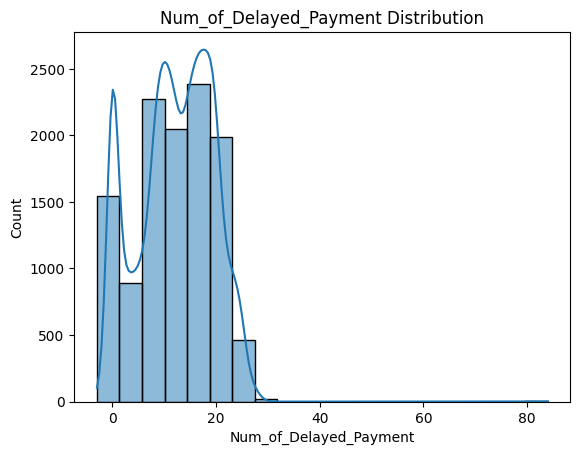

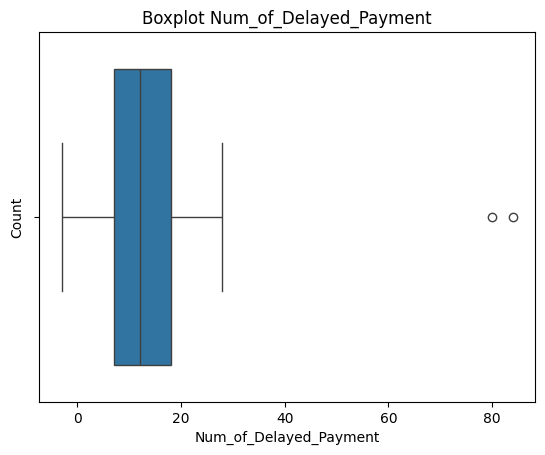

In [30]:
sns.histplot(data=df1, x='Num_of_Delayed_Payment', bins=20, kde=True)
plt.xlabel('Num_of_Delayed_Payment')
plt.ylabel('Count')
plt.title('Num_of_Delayed_Payment Distribution')
plt.show()
sns.boxplot(data=df1, x='Num_of_Delayed_Payment')
plt.xlabel('Num_of_Delayed_Payment')
plt.ylabel('Count')
plt.title('Boxplot Num_of_Delayed_Payment')
plt.show()

Number of delayed payment are persent only two outlier

Credit_Score
Standard    55.606230
Poor        28.655021
Good        15.738749
Name: proportion, dtype: float64

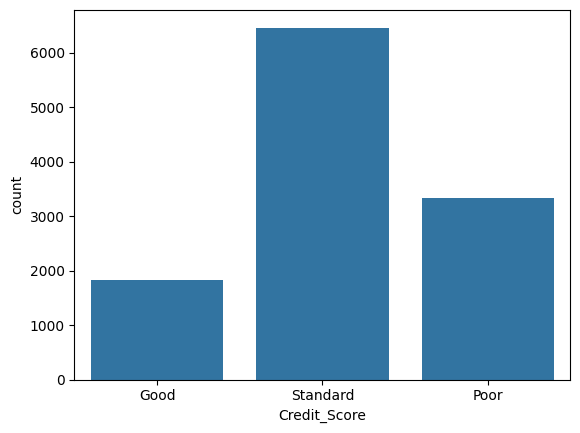

In [31]:
df1['Credit_Score'].value_counts()
sns.countplot(data=df1, x='Credit_Score')
df1['Credit_Score'].value_counts(normalize=True) * 100

Bivariate Analysis

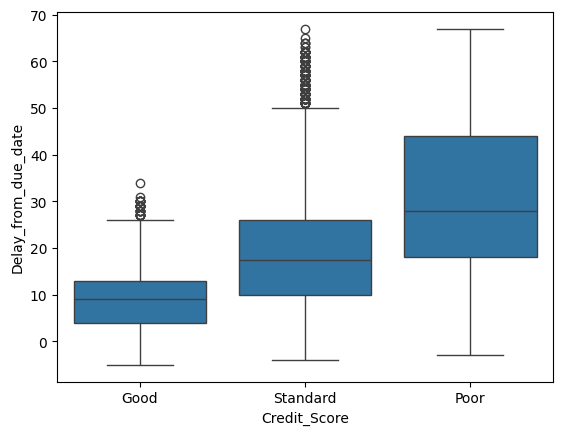

In [32]:
sns.boxplot(data=df1, x='Credit_Score', y='Delay_from_due_date')
plt.show()

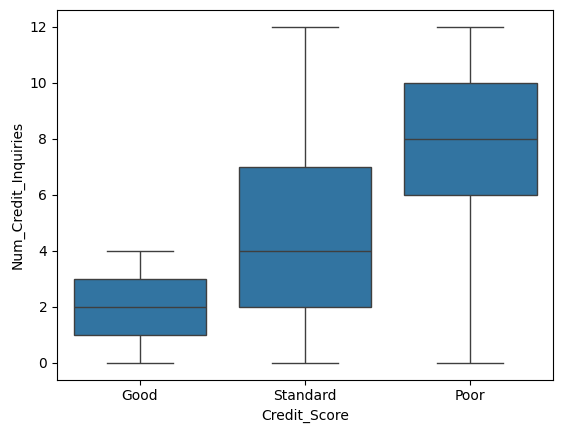

In [33]:
sns.boxplot(data=df1, x='Credit_Score', y='Num_Credit_Inquiries')
plt.show()

In [34]:
df1.columns

Index(['Age', 'Occupation', 'Annual_Income', 'Monthly_Inhand_Salary',
       'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan',
       'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt',
       'Credit_Utilization_Ratio', 'Payment_of_Min_Amount',
       'Total_EMI_per_month', 'Amount_invested_monthly', 'Payment_Behaviour',
       'Monthly_Balance', 'Credit_Score', 'Monthly_Balance ',
       'Credit_History_Age_month'],
      dtype='str')

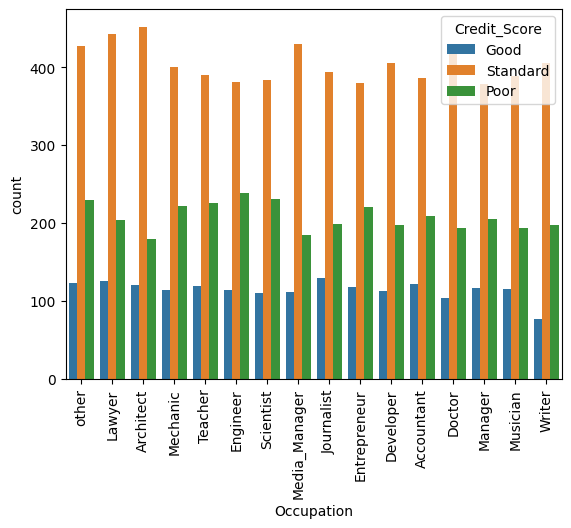

In [35]:
sns.countplot(data=df1, x='Occupation', hue='Credit_Score', order=df1['Occupation'].value_counts().index)
plt.xticks(rotation='vertical')
plt.show()

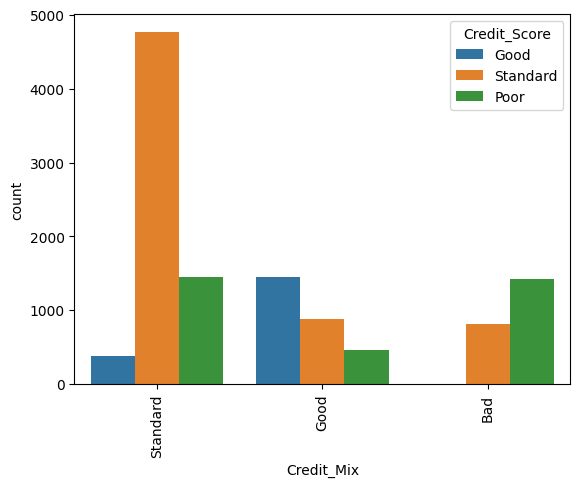

In [36]:
sns.countplot(data=df1, x='Credit_Mix', hue='Credit_Score', order=df1['Credit_Mix'].value_counts().index)
plt.xticks(rotation='vertical')
plt.show()

Standard credit mix is high standrd credit score

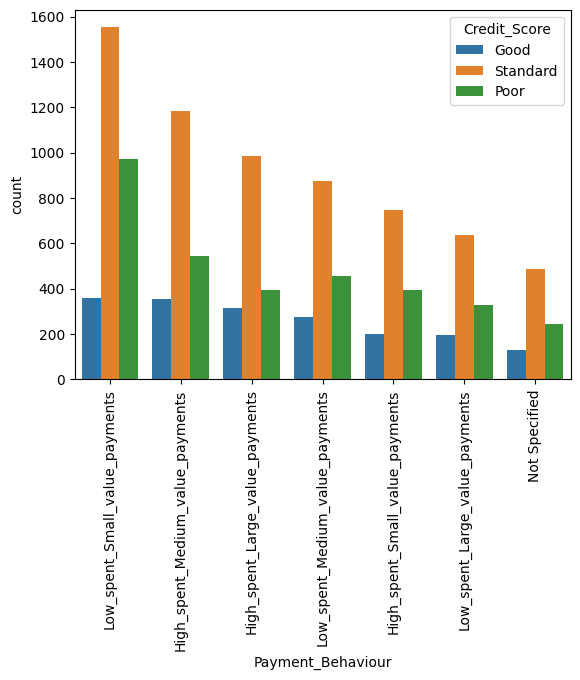

In [37]:
sns.countplot(data=df1, x='Payment_Behaviour', hue='Credit_Score', order=df1['Payment_Behaviour'].value_counts().index)
plt.xticks(rotation='vertical')
plt.show()

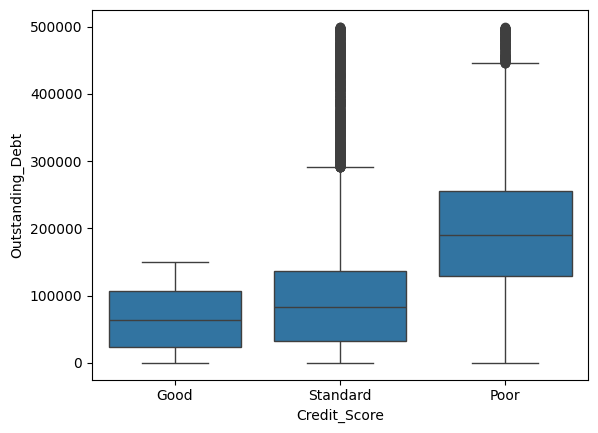

In [38]:
sns.boxplot(data=df1, x='Credit_Score', y='Outstanding_Debt')
plt.show()

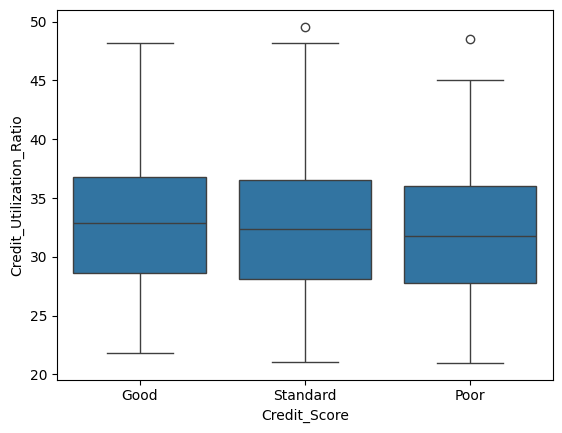

In [39]:
sns.boxplot(data=df1, x='Credit_Score', y='Credit_Utilization_Ratio')
plt.show()

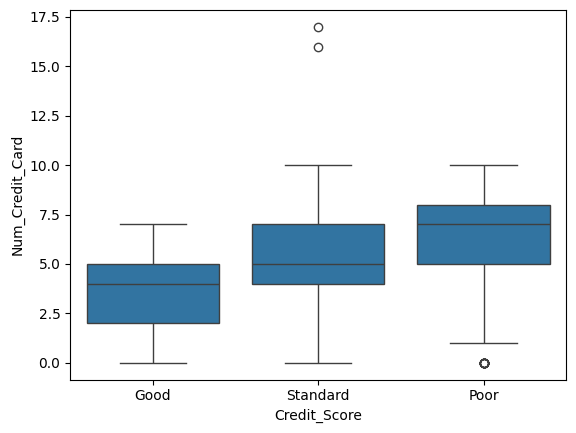

In [40]:
sns.boxplot(data=df1, x='Credit_Score', y='Num_Credit_Card')
plt.show()

Encoding categorical Columns $ Feature Scaling

In [41]:
df1['Credit_Score'].value_counts()

Credit_Score
Standard    6462
Poor        3330
Good        1829
Name: count, dtype: int64

In [42]:
df1['Credit_Mix'].value_counts()

Credit_Mix
Standard    6597
Good        2790
Bad         2234
Name: count, dtype: int64

In [43]:
df1.shape

(11621, 23)

In [44]:
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
le = LabelEncoder()
le.fit_transform(df1['Credit_Score'])
df1['Credit_Score']=le.transform(df1['Credit_Score'])
order = [['Bad','Standard','Good']]



In [45]:
df1.columns

Index(['Age', 'Occupation', 'Annual_Income', 'Monthly_Inhand_Salary',
       'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan',
       'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt',
       'Credit_Utilization_Ratio', 'Payment_of_Min_Amount',
       'Total_EMI_per_month', 'Amount_invested_monthly', 'Payment_Behaviour',
       'Monthly_Balance', 'Credit_Score', 'Monthly_Balance ',
       'Credit_History_Age_month'],
      dtype='str')

In [46]:
df1 = pd.get_dummies(
    df1,
    columns=['Occupation', 'Credit_Mix', 'Payment_Behaviour', 'Payment_of_Min_Amount'],
    drop_first=True,
    dtype=int
)



In [47]:
from sklearn.model_selection import train_test_split
X = df1.drop("Credit_Score", axis=1)
y = df1["Credit_Score"]


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=9, stratify=y
)
X_train.shape

(9296, 43)

In [48]:
X_test.shape

(2325, 43)

In [49]:
from sklearn.preprocessing import MinMaxScaler


sc = MinMaxScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)
X_train

array([[6.09756098e-01, 2.97961896e-10, 1.99273225e-01, ...,
        0.00000000e+00, 1.00000000e+00, 0.00000000e+00],
       [4.14634146e-01, 2.53813209e-11, 1.86450361e-01, ...,
        1.00000000e+00, 0.00000000e+00, 1.00000000e+00],
       [2.43902439e-01, 4.82776267e-10, 3.39536296e-01, ...,
        0.00000000e+00, 0.00000000e+00, 1.00000000e+00],
       ...,
       [2.92682927e-01, 9.67759928e-10, 7.09321902e-01, ...,
        0.00000000e+00, 1.00000000e+00, 0.00000000e+00],
       [6.82926829e-01, 4.38781217e-10, 3.27612143e-01, ...,
        0.00000000e+00, 0.00000000e+00, 1.00000000e+00],
       [2.19512195e-01, 5.02120607e-10, 3.70239518e-01, ...,
        0.00000000e+00, 0.00000000e+00, 1.00000000e+00]], shape=(9296, 43))

Model Building

In [50]:
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split
from collections import Counter

In [51]:
ros=RandomOverSampler(random_state=40)
X_train,y_train=ros.fit_resample(X_train, y_train)

Logistic Regression 

In [52]:
import pandas as pd 
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

In [53]:
X = df1.select_dtypes(include='number').drop(columns=['Credit_Score'])
X = X.astype(float)
X_const = add_constant(X)
vif_data = pd.DataFrame()
vif_data['Features'] = X_const.columns
vif_data['VIF'] = [
    variance_inflation_factor(X_const.values, i)
    for i in range(X_const.shape[1])
]
print(vif_data)

                                             Features       VIF
0                                               const  1.000000
1                                                 Age  1.098788
2                                       Annual_Income  1.019635
3                               Monthly_Inhand_Salary  1.269521
4                                   Num_Bank_Accounts  1.978324
5                                     Num_Credit_Card  1.479834
6                                       Interest_Rate  2.341721
7                                         Num_of_Loan  1.009260
8                                 Delay_from_due_date  2.023443
9                              Num_of_Delayed_Payment  1.494600
10                               Changed_Credit_Limit  1.370106
11                               Num_Credit_Inquiries  2.735797
12                                   Outstanding_Debt  1.997819
13                           Credit_Utilization_Ratio  1.045984
14                                Total_

In [54]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score
lr=LogisticRegression()
lr.fit(X_train, y_train)
y_pred=lr.predict(X_test)
y_train_pred=lr.predict(X_train)


In [55]:
X_train.shape

(15507, 43)

In [56]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_train, y_train_pred)
precision = precision_score(y_train, y_train_pred, average='weighted', zero_division=0)
recall = recall_score(y_train, y_train_pred, average='weighted', zero_division=0)
f1 = f1_score(y_train, y_train_pred, average='weighted', zero_division=0)
confusion = confusion_matrix(y_train, y_train_pred)
report = classification_report(y_train, y_train_pred, zero_division=0)

print('Accuracy:', accuracy)
print('Precision:', precision)
print('Recall:', recall)
print('F1 Score:', f1)
print('Confusion Matrix:\n', confusion)
print('Classification Report:\n', report)

Accuracy: 0.7709421551557362
Precision: 0.7726098098168277
Recall: 0.7709421551557362
F1 Score: 0.7677572729151296
Confusion Matrix:
 [[4705  133  331]
 [ 670 3797  702]
 [ 863  853 3453]]
Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.91      0.82      5169
           1       0.79      0.73      0.76      5169
           2       0.77      0.67      0.72      5169

    accuracy                           0.77     15507
   macro avg       0.77      0.77      0.77     15507
weighted avg       0.77      0.77      0.77     15507



In [57]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
confusion = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred, zero_division=0)

print('Accuracy:', accuracy)
print('Precision:', precision)
print('Recall:', recall)
print('F1 Score:', f1)
print('Confusion Matrix:\n', confusion)
print('Classification Report:\n', report)

Accuracy: 0.7053763440860215
Precision: 0.7520194633502946
Recall: 0.7053763440860215
F1 Score: 0.7101028768709856
Confusion Matrix:
 [[333   4  29]
 [ 77 487 102]
 [234 239 820]]
Classification Report:
               precision    recall  f1-score   support

           0       0.52      0.91      0.66       366
           1       0.67      0.73      0.70       666
           2       0.86      0.63      0.73      1293

    accuracy                           0.71      2325
   macro avg       0.68      0.76      0.70      2325
weighted avg       0.75      0.71      0.71      2325



Decision Tree classifier 

In [58]:
from sklearn.tree import DecisionTreeClassifier
dt=DecisionTreeClassifier(random_state=40)
dt.fit(X_train, y_train)
y_pred=dt.predict(X_test)
y_train_pred=dt.predict(X_train)
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_train, y_train_pred)
precision = precision_score(y_train, y_train_pred, average='weighted', zero_division=0)
recall = recall_score(y_train, y_train_pred, average='weighted', zero_division=0)
f1 = f1_score(y_train, y_train_pred, average='weighted', zero_division=0)
confusion = confusion_matrix(y_train, y_train_pred)
report = classification_report(y_train, y_train_pred, zero_division=0)

print('Accuracy:', accuracy)
print('Precision:', precision)
print('Recall:', recall)
print('F1 Score:', f1)
print('Confusion Matrix:\n', confusion)
print('Classification Report:\n', report)


Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
Confusion Matrix:
 [[5169    0    0]
 [   0 5169    0]
 [   0    0 5169]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      5169
           1       1.00      1.00      1.00      5169
           2       1.00      1.00      1.00      5169

    accuracy                           1.00     15507
   macro avg       1.00      1.00      1.00     15507
weighted avg       1.00      1.00      1.00     15507



In [59]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
confusion = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred, zero_division=0)

print('Accuracy:', accuracy)
print('Precision:', precision)
print('Recall:', recall)
print('F1 Score:', f1)
print('Confusion Matrix:\n', confusion)
print('Classification Report:\n', report)

Accuracy: 0.6894623655913978
Precision: 0.6897271820503547
Recall: 0.6894623655913978
F1 Score: 0.6895562072336267
Confusion Matrix:
 [[217  50  99]
 [ 40 409 217]
 [121 195 977]]
Classification Report:
               precision    recall  f1-score   support

           0       0.57      0.59      0.58       366
           1       0.63      0.61      0.62       666
           2       0.76      0.76      0.76      1293

    accuracy                           0.69      2325
   macro avg       0.65      0.65      0.65      2325
weighted avg       0.69      0.69      0.69      2325



Decision tree is over fitting.and not for genralization

In [60]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

dt_pre = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    max_leaf_nodes=20,
    random_state=42
)

dt_pre.fit(X_train, y_train)

y_train_pred = dt_pre.predict(X_train)
y_test_pred = dt_pre.predict(X_test)

print("Train Accuracy:",
      accuracy_score(y_train, y_train_pred))

print("Test Accuracy:",
      accuracy_score(y_test, y_test_pred))

Train Accuracy: 0.7866124975817372
Test Accuracy: 0.7006451612903226


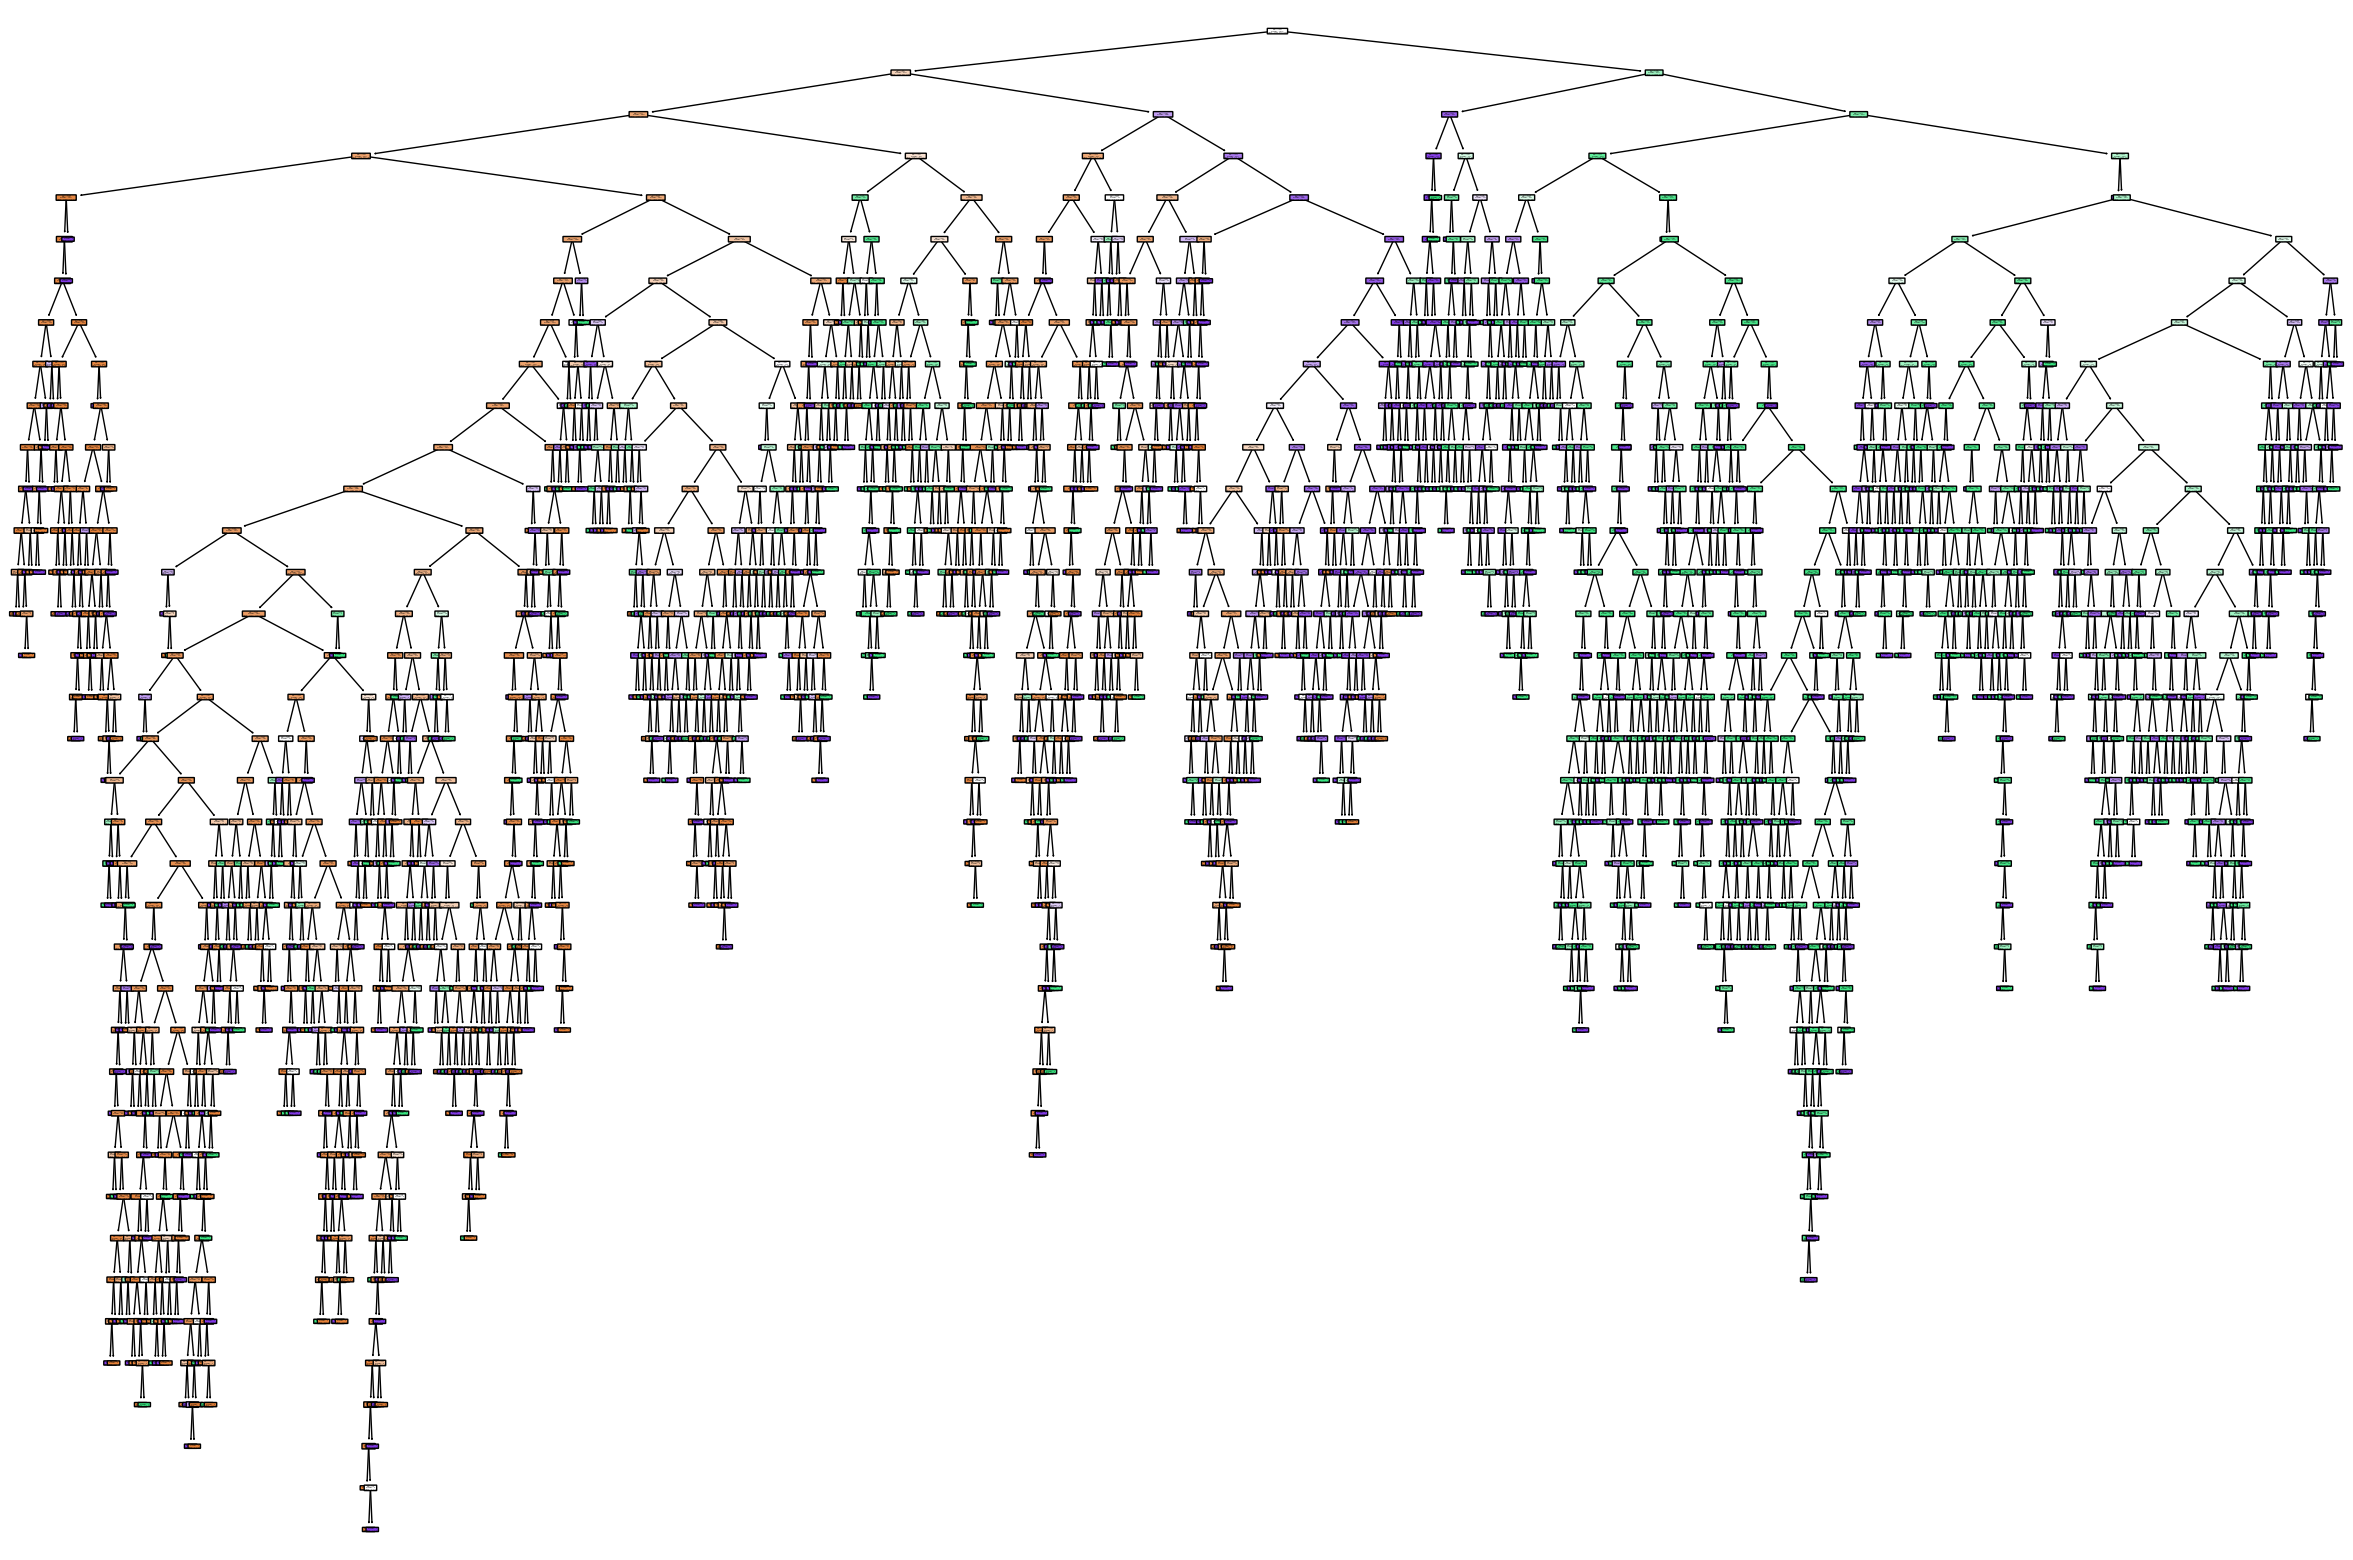

In [62]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train, y_train)
plt.figure(figsize=(30,20))
plot_tree(dt,filled=True, rounded=True,feature_names=pd.DataFrame(X_train).columns)
plt.show()

In [ ]:
path = dt.cost_complexity_pruning_path(
    X_train,
    y_train
)

ccp_alphas = path.ccp_alphas

print(ccp_alphas)

[0.00000000e+00 4.28404904e-05 4.29051823e-05 5.45408431e-05
 6.08367980e-05 6.09043944e-05 6.10012218e-05 6.10929529e-05
 6.10929529e-05 6.10929529e-05 6.15557783e-05 6.15557783e-05
 6.18000473e-05 6.18368549e-05 6.20067364e-05 6.20067364e-05
 6.20535339e-05 6.20985982e-05 6.22633160e-05 6.23374390e-05
 6.23374390e-05 6.25328542e-05 6.25328542e-05 6.27441138e-05
 6.28334929e-05 6.28690523e-05 6.29141521e-05 6.29516010e-05
 6.29516010e-05 6.29873081e-05 6.31149419e-05 6.31709445e-05
 6.32225548e-05 6.32225548e-05 6.32702699e-05 6.32759823e-05
 6.32928021e-05 6.32928021e-05 6.33037581e-05 6.33073655e-05
 6.33214468e-05 6.33354522e-05 6.33751609e-05 6.34468929e-05
 6.34492839e-05 6.35432936e-05 6.35524116e-05 6.36531222e-05
 6.36637675e-05 6.36707147e-05 6.37069211e-05 6.38152662e-05
 6.38728439e-05 6.39584239e-05 6.40263844e-05 6.41023977e-05
 6.41054260e-05 6.43838267e-05 6.44870059e-05 6.44870059e-05
 6.44870059e-05 6.44870059e-05 6.44870059e-05 6.44870059e-05
 6.44870059e-05 6.448700

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# 1. Pehle full tree banao
tree = DecisionTreeClassifier(random_state=42)

tree.fit(X_train, y_train)

# 2. CCP alpha values nikalo
path = tree.cost_complexity_pruning_path(X_train, y_train)
alphas = path.ccp_alphas

# 3. Har alpha ke liye tree train karo
best_alpha = 0
best_score = 0

for alpha in alphas:

    model = DecisionTreeClassifier(
        ccp_alpha=alpha,
        random_state=42
    )

    model.fit(X_train, y_train)

    score = model.score(X_test, y_test)

    if score > best_score:
        best_score = score
        best_alpha = alpha

# 4. Best alpha ke saath final pruned tree
final_tree = DecisionTreeClassifier(
    ccp_alpha=best_alpha,
    random_state=42
)

final_tree.fit(X_train, y_train)

# 5. Prediction
y_pred = final_tree.predict(X_test)
y_train_pred = final_tree.predict(X_train)
# 6. Accuracy
print("Best ccp_alpha:", best_alpha)
print("Train Accuracy:", final_tree.score(X_train, y_train))
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(classification_report(y_train, y_train_pred))


Best ccp_alpha: 0.0005647719450594052
Train Accuracy: 0.8262720061907526
Test Accuracy: 0.7329032258064516
              precision    recall  f1-score   support

           0       0.55      0.93      0.69       366
           1       0.67      0.81      0.73       666
           2       0.91      0.64      0.75      1293

    accuracy                           0.73      2325
   macro avg       0.71      0.79      0.73      2325
weighted avg       0.78      0.73      0.74      2325

              precision    recall  f1-score   support

           0       0.80      0.95      0.87      5169
           1       0.82      0.85      0.84      5169
           2       0.87      0.68      0.76      5169

    accuracy                           0.83     15507
   macro avg       0.83      0.83      0.82     15507
weighted avg       0.83      0.83      0.82     15507



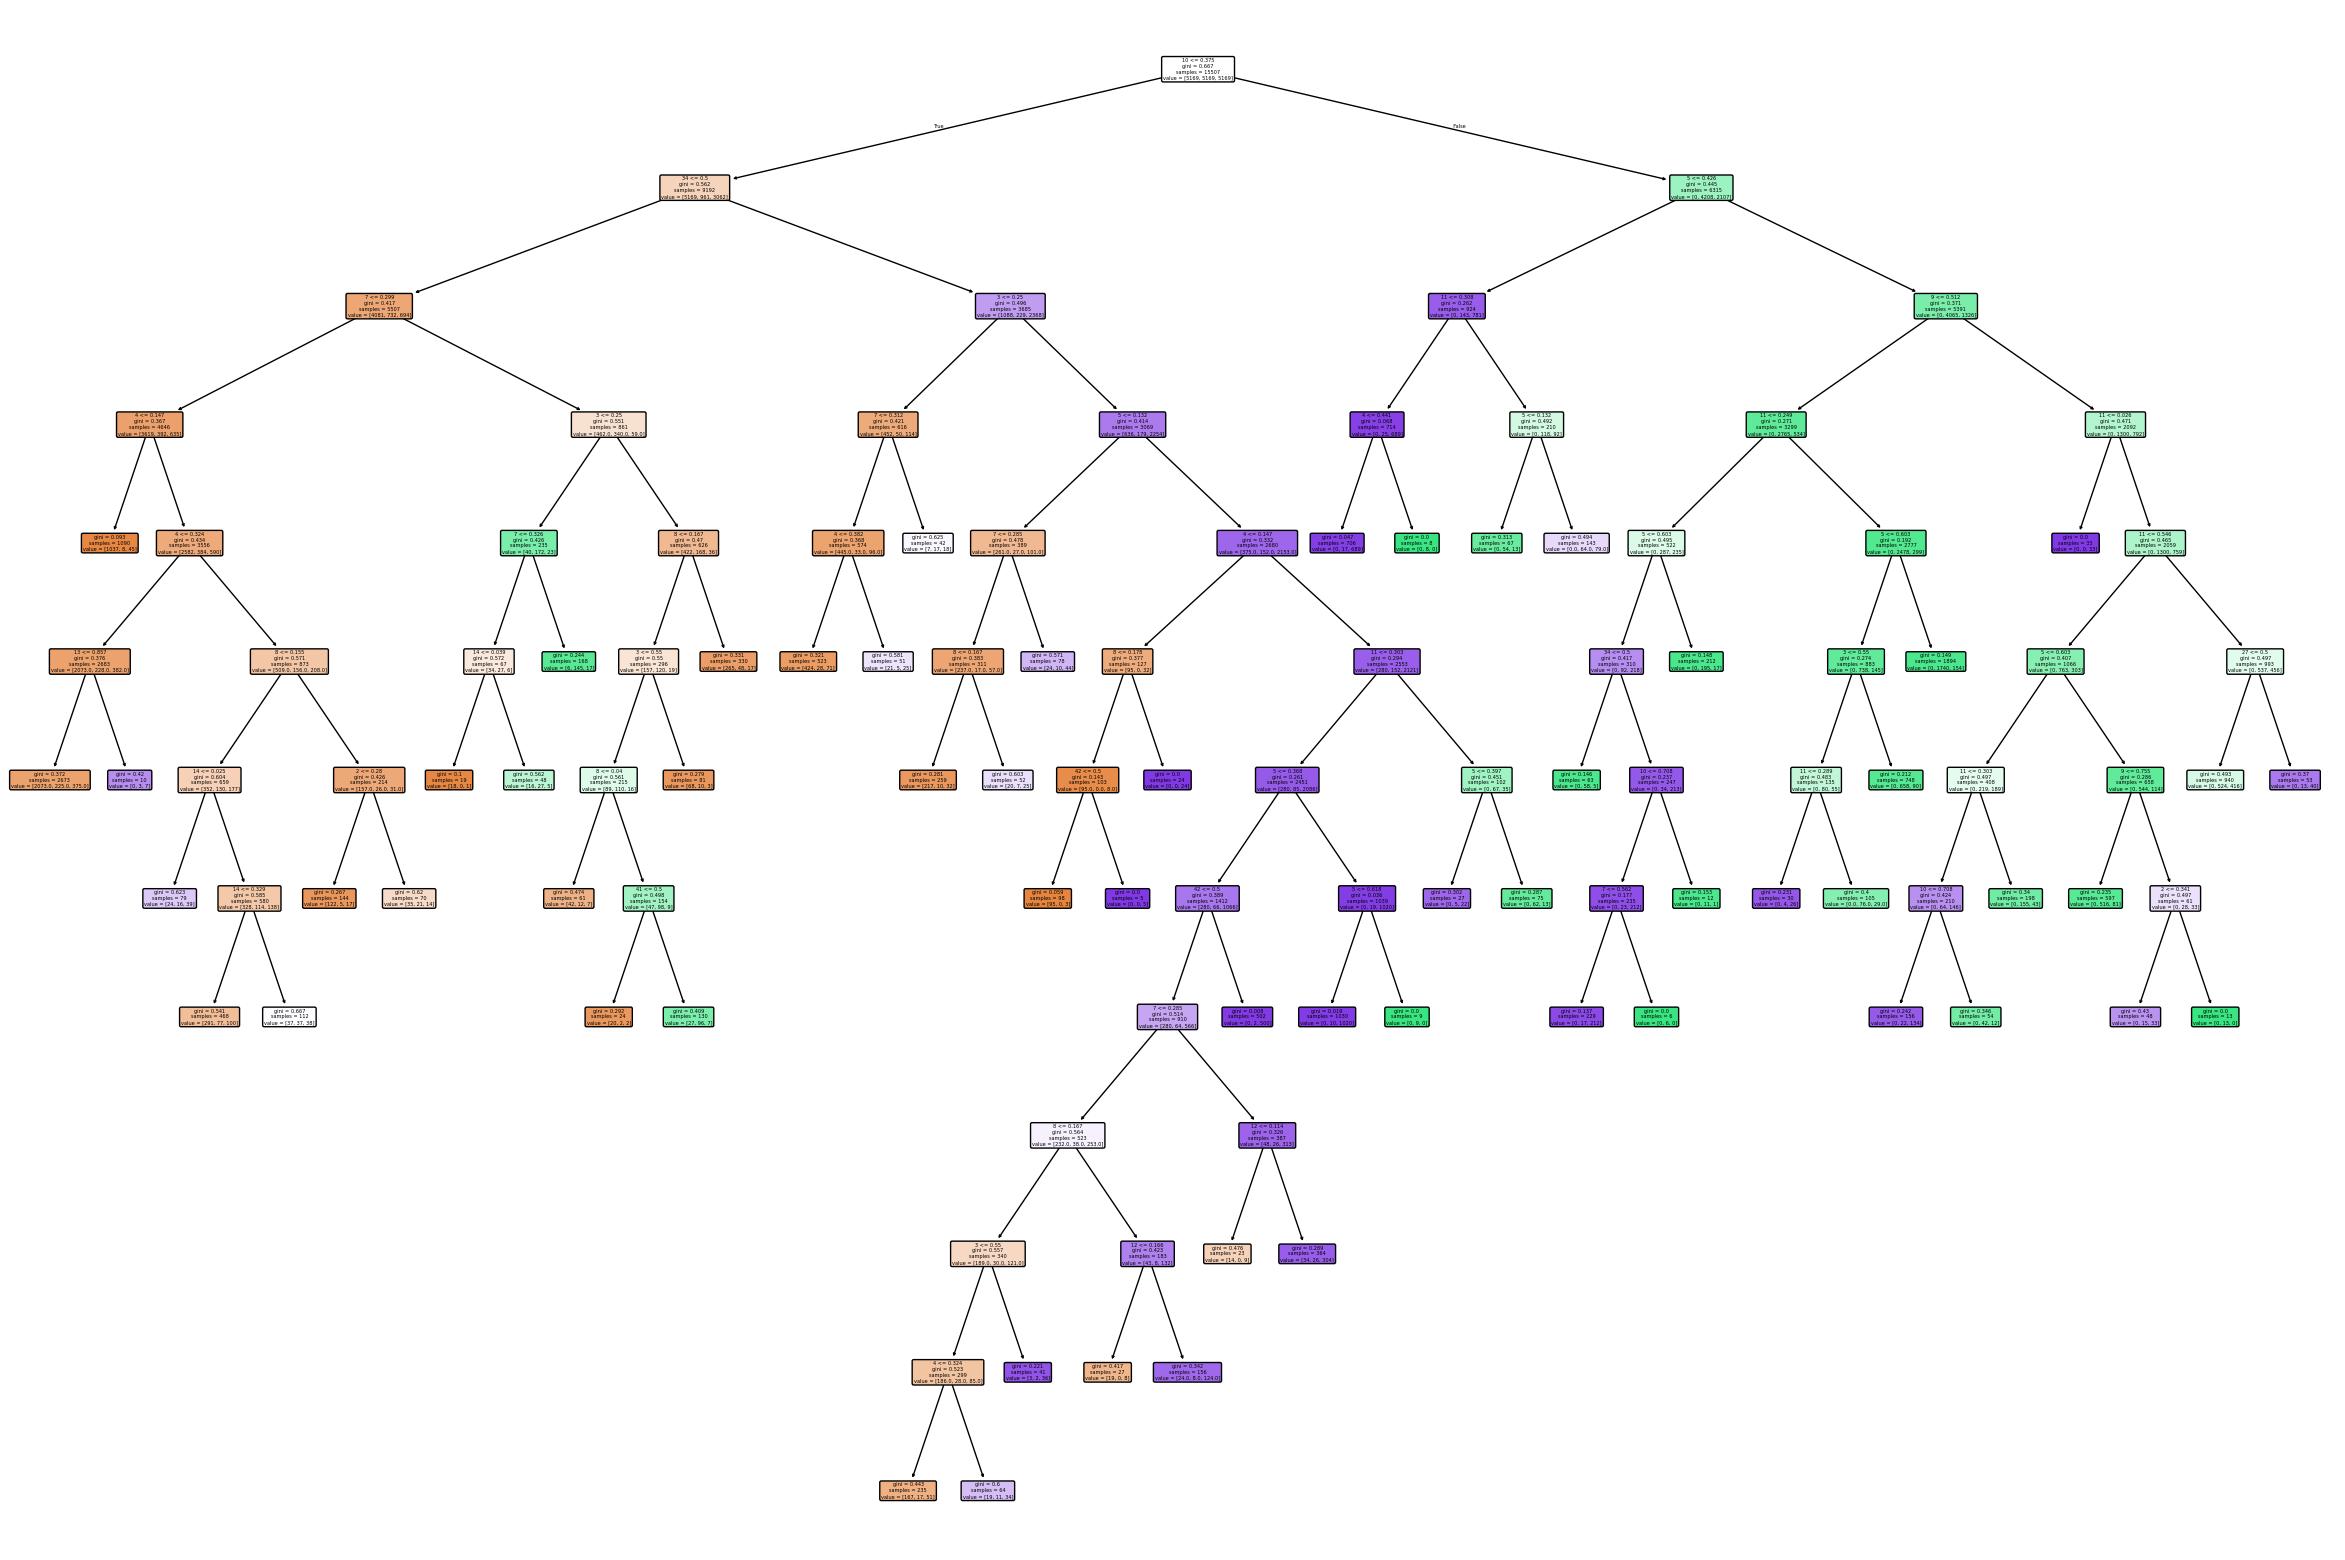

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt


plt.figure(figsize=(30,20))
plot_tree(final_tree,filled=True, rounded=True, feature_names=pd.DataFrame(X_train).columns)
plt.show()

Now genralixzation test data is better

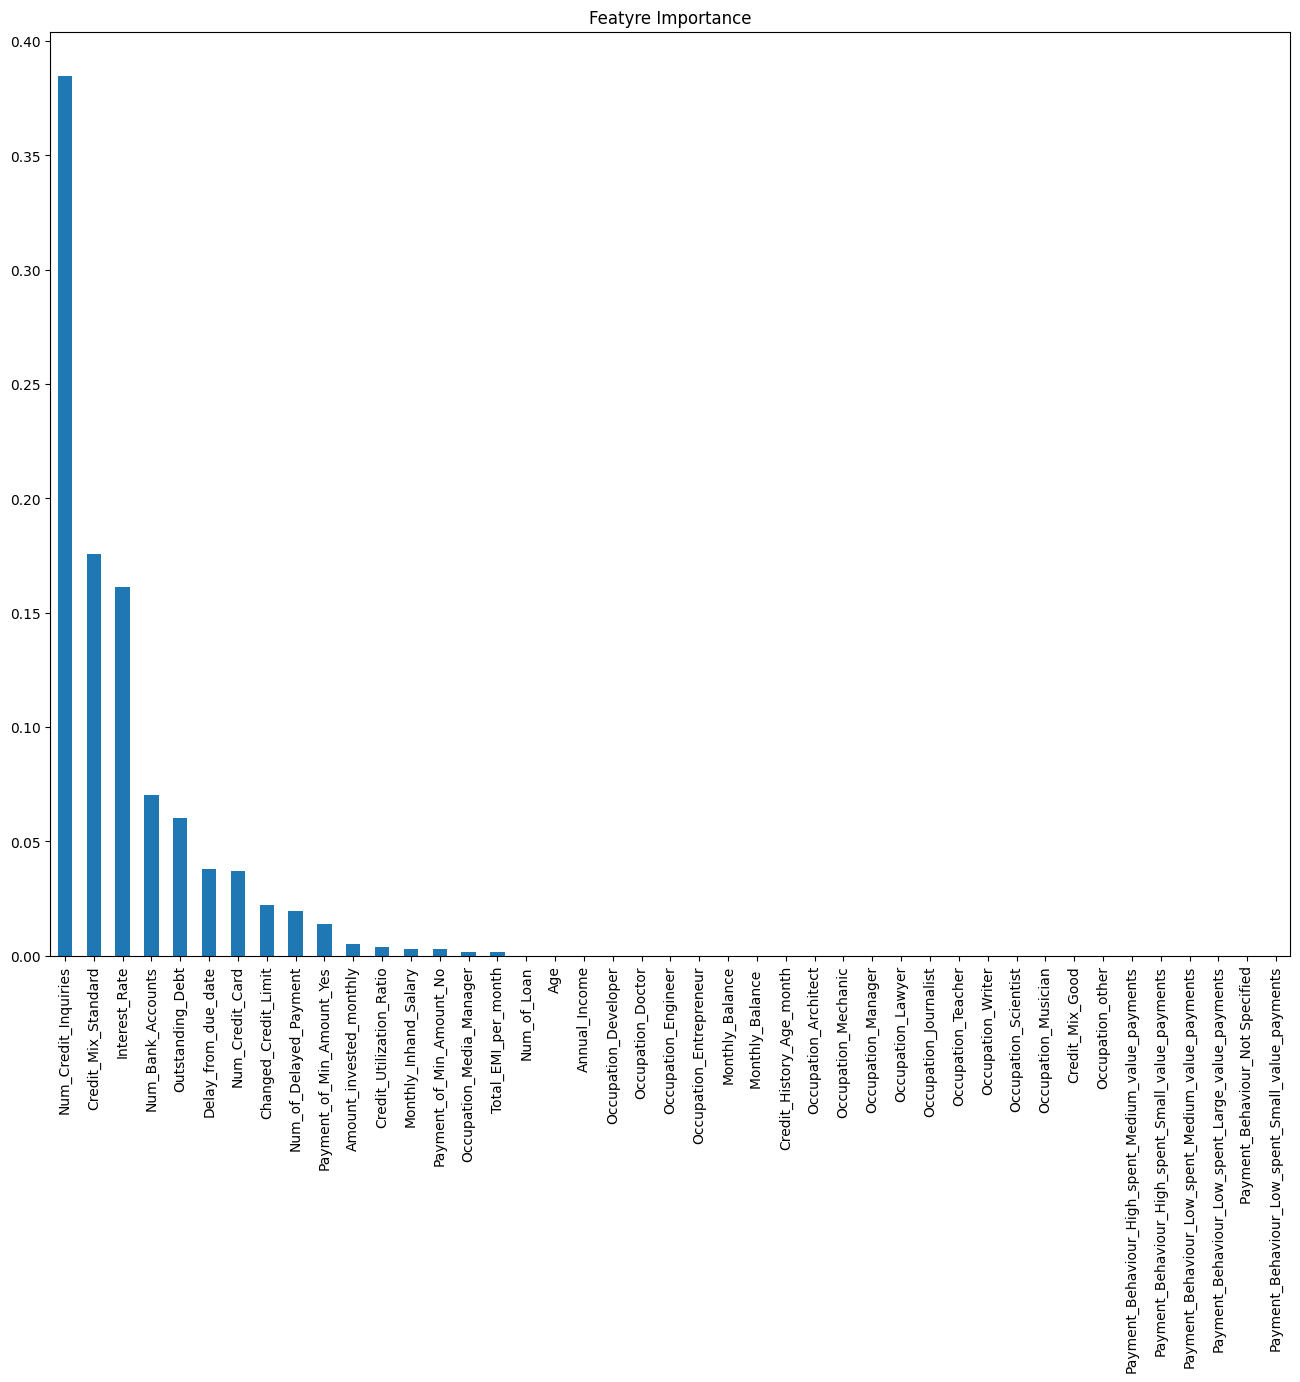

In [ ]:
from pandas import Series



plt.figure(figsize=(16,12))
feature_imp=pd.Series(final_tree.feature_importances_, index=df1.drop("Credit_Score", axis=1). columns).sort_values(ascending=False)
feature_imp.plot(kind='bar', title='Featyre Importance')
plt.show()

In [68]:
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier(random_state=40,max_depth=20,class_weight={0:1,1:2,2:3})
rf.fit(X_train,y_train)
y_train_pred=rf.predict(X_train)
y_pred=rf.predict(X_test)
print(classification_report(y_train,y_train_pred))
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5169
           1       1.00      1.00      1.00      5169
           2       1.00      1.00      1.00      5169

    accuracy                           1.00     15507
   macro avg       1.00      1.00      1.00     15507
weighted avg       1.00      1.00      1.00     15507

              precision    recall  f1-score   support

           0       0.55      0.85      0.67       366
           1       0.73      0.75      0.74       666
           2       0.86      0.71      0.78      1293

    accuracy                           0.74      2325
   macro avg       0.71      0.77      0.73      2325
weighted avg       0.77      0.74      0.75      2325



this is also obverfiting nature even thought random forest reduces overfiting   compared to decision tree ,it can still memorize the training data if not constrauined .Since i want to improve recall the class1, so let introduce another rfmodel which has higher recall for class 1

Higher Recall rate Rf Model

In [69]:
from sklearn.ensemble import RandomForestClassifier
rf1=RandomForestClassifier(random_state=40,max_depth=10, n_estimators=10, max_features=0.8,class_weight={0:1,1:2,2:3})
rf1.fit(X_train,y_train)
y_train_pred=rf1.predict(X_train)
y_pred=rf1.predict(X_test)
print(classification_report(y_train,y_train_pred))
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.87      0.92      0.89      5169
           1       0.93      0.89      0.91      5169
           2       0.86      0.85      0.86      5169

    accuracy                           0.89     15507
   macro avg       0.89      0.89      0.89     15507
weighted avg       0.89      0.89      0.89     15507

              precision    recall  f1-score   support

           0       0.58      0.78      0.67       366
           1       0.73      0.74      0.74       666
           2       0.84      0.75      0.79      1293

    accuracy                           0.75      2325
   macro avg       0.72      0.76      0.73      2325
weighted avg       0.77      0.75      0.76      2325



there is trade off between the accuracy and recall .Now we have lesser accuracy

Constructing voting Ensemble with Both Rf Models 

In [70]:
from sklearn.ensemble import VotingClassifier

voting = VotingClassifier(
    estimators=[
        ('High_Accuracy', rf),
        ('high_Recall', rf1)
    ],
    voting='soft'
)

voting.fit(X_train, y_train)

y_pred = voting.predict(X_test)
y_train_pred=voting.predict(X_train)
print("Accuracy:", voting.score(X_test, y_test))
print(classification_report(y_train, y_train_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7475268817204301
              precision    recall  f1-score   support

           0       0.96      0.98      0.97      5169
           1       0.97      0.96      0.97      5169
           2       0.96      0.94      0.95      5169

    accuracy                           0.96     15507
   macro avg       0.96      0.96      0.96     15507
weighted avg       0.96      0.96      0.96     15507

              precision    recall  f1-score   support

           0       0.57      0.82      0.67       366
           1       0.72      0.74      0.73       666
           2       0.85      0.73      0.78      1293

    accuracy                           0.75      2325
   macro avg       0.71      0.76      0.73      2325
weighted avg       0.77      0.75      0.75      2325



Now we got satisfactory accuracy(75%) with 82% recall rate of class poor.

SUPPORT VECTOR CLASSIFICATION

In [63]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# SVM model
svm = SVC(
    kernel='rbf',
    C=1,
    random_state=42
)

# Train
svm.fit(X_train, y_train)

# Prediction
y_pred = svm.predict(X_test)
y_train_pred=svm.predict(X_train)
# Accuracy
print("Accuracy:", accuracy_score(y_train, y_train_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))
# Detailed report
print(classification_report(y_train, y_train_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8147288321403238
Accuracy: 0.7165591397849462
              precision    recall  f1-score   support

           0       0.76      0.98      0.85      5169
           1       0.83      0.81      0.82      5169
           2       0.90      0.66      0.76      5169

    accuracy                           0.81     15507
   macro avg       0.83      0.81      0.81     15507
weighted avg       0.83      0.81      0.81     15507

              precision    recall  f1-score   support

           0       0.51      0.94      0.66       366
           1       0.68      0.77      0.72       666
           2       0.91      0.63      0.74      1293

    accuracy                           0.72      2325
   macro avg       0.70      0.78      0.71      2325
weighted avg       0.78      0.72      0.72      2325



this model is show overfiting but its accuracy is acceptable.

In [ ]:
from sklearn.inspection import permutation_importance

importance = permutation_importance(
    svm,
    X_test,
    y_test,
    n_repeats=5,
    random_state=42,
    scoring='accuracy'
)

feature_names = df1.drop('Credit_Score', axis=1).columns
feature_imp = pd.Series(
    importance.importances_mean,
    index=feature_names
).sort_values(ascending=False)

feature_imp.plot(kind='bar', figsize=(16, 12), title='SVM Feature Importance')
plt.tight_layout()
plt.show()

XgBoost Classifier

In [64]:
from xgboost import XGBClassifier
xgb=XGBClassifier(n_estimators=2,random_state=40, num_parallel_tree=3)
xgb.fit(X_train,y_train)

,"objective objective: str | xgboost.objective.Objective | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBR

In [65]:
y_train_pred=xgb.predict(X_train)
y_pred=xgb.predict(X_test)
print(classification_report(y_train,y_train_pred))
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.78      0.97      0.87      5169
           1       0.85      0.84      0.85      5169
           2       0.91      0.69      0.79      5169

    accuracy                           0.84     15507
   macro avg       0.85      0.84      0.83     15507
weighted avg       0.85      0.84      0.83     15507

              precision    recall  f1-score   support

           0       0.53      0.95      0.68       366
           1       0.70      0.78      0.74       666
           2       0.91      0.66      0.76      1293

    accuracy                           0.74      2325
   macro avg       0.71      0.79      0.73      2325
weighted avg       0.79      0.74      0.74      2325



this model is show overfiting but its accuracy is acceptable.

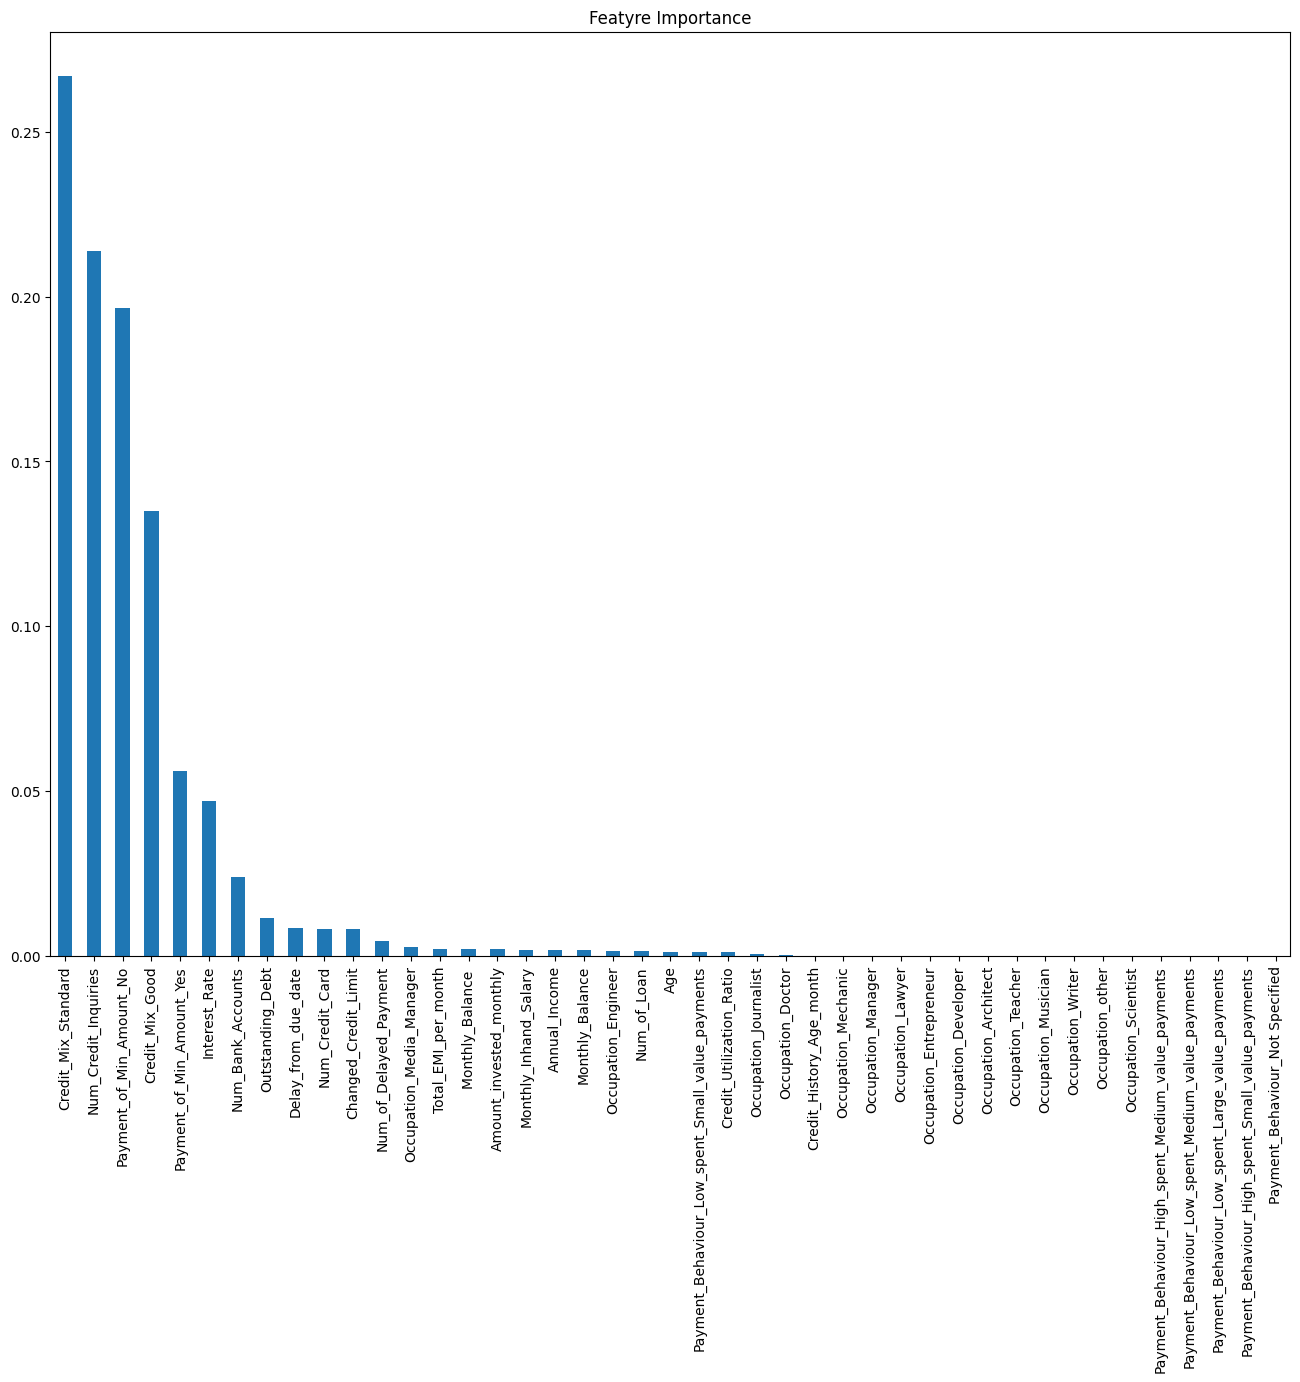

In [66]:
plt.figure(figsize=(16,12))
feature_imp=pd.Series(xgb.feature_importances_, index=df1.drop("Credit_Score", axis=1). columns).sort_values(ascending=False)
feature_imp.plot(kind='bar', title='Featyre Importance')
plt.show()


Stepping toword the Final Model

In [78]:
feature_names = df1.drop('Credit_Score', axis=1).columns

l1 = feature_names[np.argsort(rf.feature_importances_)[::-1]].tolist()
l2 = feature_names[np.argsort(rf1.feature_importances_)[::-1]].tolist()
l3 = feature_names[np.argsort(xgb.feature_importances_)[::-1]].tolist()

top_features = list(dict.fromkeys(l1 + l2 + l3))
print('Number of combined features:', len(top_features))
print('Top features:', top_features[:10])

Number of combined features: 43
Top features: ['Outstanding_Debt', 'Interest_Rate', 'Num_Credit_Inquiries', 'Delay_from_due_date', 'Credit_Mix_Standard', 'Changed_Credit_Limit', 'Num_Credit_Card', 'Num_Bank_Accounts', 'Credit_Mix_Good', 'Num_of_Delayed_Payment']


In [85]:
from sklearn.model_selection import train_test_split

X1 = df1[top_features].copy()
for column in X1.select_dtypes(include='object').columns:
    X1[column] = pd.to_numeric(X1[column], errors='coerce')

X1 = X1.fillna(X1.median()).astype(float)
y = df1['Credit_Score']

X_train, X_test, y_train, y_test = train_test_split(
    X1, y, test_size=0.2, random_state=9, stratify=y
)

rf = RandomForestClassifier(
    max_depth=20,
    random_state=42
)

rf1 = RandomForestClassifier(
    n_estimators=10,
    max_depth=10,
    random_state=42
)

xgb = XGBClassifier(
    n_estimators=100,
    random_state=42
)

In [86]:
from sklearn.ensemble import VotingClassifier

X_train = X_train.apply(pd.to_numeric, errors='coerce').fillna(0).astype(float)
X_test = X_test.apply(pd.to_numeric, errors='coerce').fillna(0).astype(float)

voting = VotingClassifier(
    estimators=[
        ('High_Accuracy', rf),
        ('high_Recall', rf1),
        ('XGB', xgb)
    ],
    voting='soft'
)

voting.fit(X_train, y_train)

y_pred = voting.predict(X_test)
y_train_pred = voting.predict(X_train)
print('Accuracy:', voting.score(X_test, y_test))
print(classification_report(y_train, y_train_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7544086021505376
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      1463
           1       0.98      0.98      0.98      2664
           2       0.99      0.99      0.99      5169

    accuracy                           0.99      9296
   macro avg       0.98      0.98      0.98      9296
weighted avg       0.99      0.99      0.99      9296

              precision    recall  f1-score   support

           0       0.62      0.73      0.67       366
           1       0.74      0.73      0.74       666
           2       0.81      0.78      0.79      1293

    accuracy                           0.75      2325
   macro avg       0.72      0.74      0.73      2325
weighted avg       0.76      0.75      0.76      2325



we got satisfactory accuracy 75% with 78 percetange recall rate of class good with only top feature insteade of 43 feature. this reduces the complexity of the model.

Hyperparameter tunning of the Final model

In [88]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import recall_score, make_scorer

class2_recall = make_scorer(
    recall_score,
    labels=[2],
    average='macro'
)

param_grid = {
    'High_Accuracy__n_estimators': [5, 10],
    'High_Accuracy__max_depth': [10, 20],
    'high_Recall__n_estimators': [10, 20],
    'high_Recall__max_depth': [10, 20]
}

grid_recall2 = GridSearchCV(
    estimator=voting,
    param_grid=param_grid,
    cv=3,
    scoring=class2_recall,
    n_jobs=-1
)

grid_recall2.fit(X_train, y_train)

y_pred = grid_recall2.predict(X_test)
print('Best parameters:', grid_recall2.best_params_)
print('Class 2 recall:', grid_recall2.best_score_)
print(classification_report(y_test, y_pred, zero_division=0))

Best parameters: {'High_Accuracy__max_depth': 10, 'High_Accuracy__n_estimators': 10, 'high_Recall__max_depth': 20, 'high_Recall__n_estimators': 20}
Class 2 recall: 0.7856451924937126
              precision    recall  f1-score   support

           0       0.62      0.74      0.67       366
           1       0.75      0.73      0.74       666
           2       0.81      0.78      0.79      1293

    accuracy                           0.76      2325
   macro avg       0.73      0.75      0.74      2325
weighted avg       0.76      0.76      0.76      2325



In [89]:
grid_recall2.best_params_

{'High_Accuracy__max_depth': 10,
 'High_Accuracy__n_estimators': 10,
 'high_Recall__max_depth': 20,
 'high_Recall__n_estimators': 20}

After hyperparameter tuning and cross validation we found the best model with accuracy 76% and 79% recall rate of class 2 using 20 top features.